# Testing the CAPM on US Equities

**Authors:** Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda, Nico Visentin

## Executive summary

This notebook asks whether the CAPM describes the returns of eight large US stocks (AAPL, BA, T, MGM, AMZN, IBM, TSLA, GOOG) measured against the S&P 500 between January 2012 and summer 2020. It then extends the test to the whole S&P 500 universe with CRSP data (2007–2023), following the approach of Fama and French (2004), *The Capital Asset Pricing Model: Theory and Evidence*.

**Data.** Sections 3–5 use a price file with the daily closing prices of the eight stocks and of the S&P 500 index (12 January 2012 to 11 August 2020). Section 6 uses the daily CRSP panel of S&P 500 constituents downloaded from WRDS, which is free of survivorship bias; Section 6.1 explains this choice.

**Market exposure (Section 3).** All eight stocks are positively correlated with the market, most strongly IBM, GOOG and AAPL and least TSLA. The correlations are not stable over time: they spike during the COVID crash, when stocks fall together, and drop around firm-specific events such as BA's 737 MAX crisis.

**Full-sample CAPM estimation (Section 4).** Full-period betas range from 0.74 (T) to 1.65 (MGM) and are all highly significant. Four stocks (MGM, BA, TSLA, AAPL) are significantly riskier than the market, and T is the only significantly defensive one. Alpha is statistically zero for five stocks, as the CAPM predicts, but TSLA (+44% a year) and AMZN (+26%) beat their risk-adjusted benchmark and IBM (−13%) lagged it. The market explains only 15–50% of daily variance. The residuals are fat-tailed, heteroskedastic and in some cases autocorrelated; HAC standard errors widen the confidence intervals but change no conclusion. The high-beta portfolio (MGM, BA, TSLA, AAPL; β = 1.35) was predicted to earn 16.8% a year and actually earned 30.0%, and the gap comes almost entirely from TSLA's alpha rather than from market risk.

**Predictive test (Section 5).** Using each stock's beta from the previous year and the market return realized in the current year, the CAPM predicts individual annual returns poorly (mean absolute error ≈ 25 percentage points). Realized returns rise with beta on average, but the slope is unstable across years (negative in 2014 and 2019, positive in the 2018 down market), statistically insignificant and driven by 2020 and a few technology winners. Errors are persistent by firm (TSLA, AMZN and AAPL above the prediction, IBM below), which points to risk factors the CAPM leaves out. Yearly betas are noisy and drift over time; a three-month estimation window destroys the beta–return relation, while one to two years works best.

**Cross-sectional tests on the S&P 500 (Section 6).** With about 470 stocks sorted into beta deciles (2010–2023), postranking betas spread from 0.62 to 1.33 and average returns rise almost linearly with beta. The flat security market line documented by Fama and French appears only faintly, and the GRS test does not reject that all decile alphas are zero (p = 0.32). The Fama–MacBeth beta premium is positive but not significant (t = 1.34). The book-to-market analysis, where the paper finds a major piece of evidence against the CAPM, could not be replicated because it requires Compustat data.

**Overall.** Beta is a meaningful measure of a stock's exposure to the market and is estimated precisely over long samples, and higher-beta stocks and portfolios did earn more on average in our data. But beta alone is a poor predictor of what an individual stock will earn in a given year, it varies over time, and the persistent firm-level errors suggest that other sources of risk matter. The main limitations (Section 7) are $r_f = 0$, the S&P 500 as a proxy for the market portfolio, price-only returns in the course data, a partial and exceptional 2020, and a small, non-random set of eight stocks.

## 1. Setup and configuration

All imports and parameters are collected here. Paths are relative to the `notebooks/` folder; see `data/README.md` for how to obtain the two data files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from scipy import stats
from scipy.stats import norm, skew, kurtosis, jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, het_white, acorr_breusch_godfrey

In [2]:
# --- Paths (relative to notebooks/) ---
DATA_DIR = Path("../data/raw")
FIG_DIR = Path("../figures")
STOCK_FILE = DATA_DIR / "Data_Stock.csv"                 # eight-stock price file (Sections 2–5)
CRSP_FILE = DATA_DIR / "crsp_sp500_2007_2023.csv.gz"     # CRSP daily S&P 500 panel (Section 6)

# --- Sample ---
STOCKS = ["AAPL", "BA", "T", "MGM", "AMZN", "IBM", "TSLA", "GOOG"]
COVID_START, COVID_END = pd.Timestamp("2020-02-19"), pd.Timestamp("2020-04-30")   # crash window used in several plots

# --- Conventions ---
RF = 0                    # risk-free rate, assumed zero throughout
TRADING_DAYS = 252        # trading days per year (annualization)

# --- Sections 3–5: eight stocks ---
CORR_WINDOW = 63                       # rolling correlation window, about one trading quarter
BETA_WINDOW = 252                      # rolling / prior-year beta window, one trading year
BETA_WINDOWS = [63, 126, 252, 504]     # estimation-window sensitivity: 3 months, ~6 months, 1 year, 2 years
HAC_LAGS = 5                           # Newey–West (HAC) lags
BG_LAGS = 5                            # Breusch–Godfrey lags

# --- Section 6: CRSP extension ---
CRSP_START, CRSP_END = None, None      # optional date filter on the CRSP file (None = full sample)
PRERANK_WINDOW = 504                   # ~2 trading years for preranking betas
MIN_OBS = 380                          # require most of the window to trust the beta
N_DECILES = 10
FM_MIN_STOCKS = 30                     # minimum number of stocks in a Fama–MacBeth cross-section

# --- Figures ---
FIG_DPI = 150
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 100


def save_fig(name, fig=None):
    """Save a figure (default: the current one) to FIG_DIR/<name>.png at 150 dpi."""
    fig = fig if fig is not None else plt.gcf()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=FIG_DPI, bbox_inches="tight")

## 2. Data

Sections 3–5 use the eight-stock price file `Data_Stock.csv`: one row per trading day from 12 January 2012 to 11 August 2020, with the closing prices of AAPL, BA, T, MGM, AMZN, IBM, TSLA and GOOG and the level of the S&P 500 index (`sp500`). The CRSP panel used in Section 6 is loaded and checked in Section 6.1.

In [3]:
course_data = pd.read_csv(STOCK_FILE, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
# Overview of the price file (structure only: the course data are not redistributed)
print("Shape:", course_data.shape)
print("Period:", course_data["Date"].min().date(), "to", course_data["Date"].max().date())
print("Columns:", list(course_data.columns))

Shape: (2159, 10)
Period: 2012-01-12 to 2020-08-11
Columns: ['Date', 'AAPL', 'BA', 'T', 'MGM', 'AMZN', 'IBM', 'TSLA', 'GOOG', 'sp500']


In [4]:
# Daily returns:

def calculate_daily_returns(course_data, stock_columns):
    """Computes the daily returns of every stock"""
    returns = course_data[["Date"]].copy()
    returns[stock_columns] = course_data[stock_columns].pct_change()   # (P_t - P_t-1) / P_t-1
    return returns.dropna()                                      # drop 1st day (no previous price)->Na

course_returns = calculate_daily_returns(course_data, STOCKS + ["sp500"])

**Note on returns.** Daily returns are simple returns, $r_t = P_t / P_{t-1} - 1$, computed from the course price file; the first day is dropped because it has no previous price.

The prices in this file appear to be split-adjusted closing prices that are **not** adjusted for dividends (IBM's first observation, 180.55 USD, is its actual trading price in January 2012), and the market series is the S&P 500 price index. Our returns therefore measure price changes only. For the comparison with the market this is mostly harmless, since the index also excludes dividends, but it penalizes the stocks whose dividend yield is well above the index's, in particular T and IBM, whose returns and alphas are somewhat understated.

## 3. Market exposure

**Research questions.**
1. Is there an apparent correlation between each stock's daily returns and the market's daily returns? How strong is it, and for which stocks?
2. How did the stocks perform relative to the market over the sample?
3. Is the relationship with the market stable over time?

### 3.1 Daily returns vs. market returns

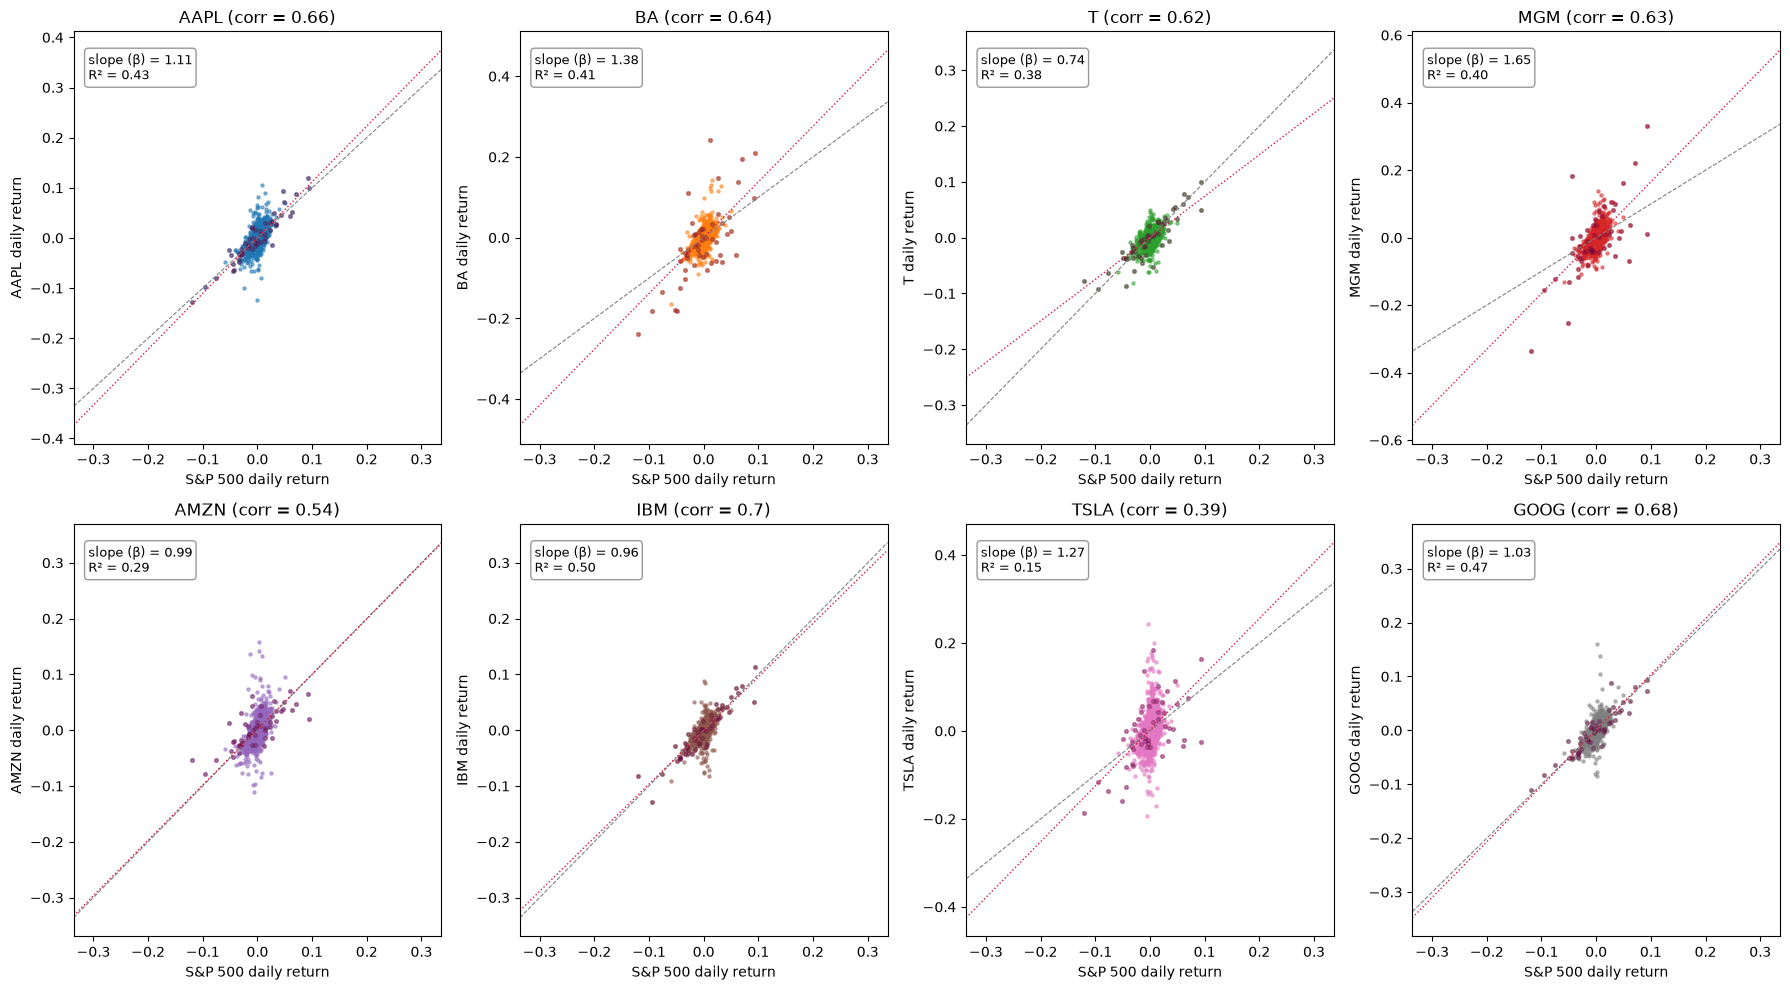

In [5]:
# Scatter plots: each stock's daily returns vs market daily returns
plt.figure(figsize=(18, 10))

# COVID crash mask and common axis limits
covid = course_returns["Date"].between(COVID_START, COVID_END)
lim = max(course_returns["sp500"].abs().max(), course_returns[STOCKS].abs().max().max())

for i, stock in enumerate(STOCKS):
    x = course_returns["sp500"]
    y = course_returns[stock]
    corr = x.corr(y)

    plt.subplot(2, 4, i + 1)
    plt.scatter(x, y, s=5, color=f"C{i}", alpha=0.5)
    plt.title(stock + " (corr = " + str(round(corr, 2)) + ")")
    plt.xlabel("S&P 500 daily return")
    plt.ylabel(stock + " daily return")

    # highlight COVID crash days on top of the original scatter
    plt.scatter(x[covid], y[covid], s=8, color="#66023C", alpha=0.3)

    # beta = 1 reference line and OLS trend line
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(-lim, lim, 100)
    plt.plot(x_line, x_line, color="gray", linestyle="--", linewidth=0.8)
    plt.plot(x_line, intercept + slope * x_line, color="crimson", linestyle=":", linewidth=1)

    # label with slope and R²
    plt.text(0.04, 0.95, f"slope (β) = {slope:.2f}\nR² = {corr**2:.2f}",
             transform=plt.gca().transAxes, ha="left", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))

    # same scale on every panel
    plt.xlim(-lim, lim)

plt.tight_layout()
save_fig("01_returns_vs_market_scatter")
plt.show()

All eight stocks are positively correlated with the S&P 500 (0.39–0.70), strongest for IBM, GOOG and AAPL and weakest for TSLA. Correlation and beta measure different things: TSLA has a high beta (1.27) but low correlation, meaning it moves strongly but largely for firm-specific reasons, while IBM tracks the market closely with a beta below 1. The market explains only 15–50% of daily variance (R²); the remainder is idiosyncratic risk, which can be diversified away. The most extreme observations are COVID crash days, when stocks moved together; MGM and BA were hit hardest, which likely inflates their betas. Finally, part of the correlation of AAPL, GOOG and IBM is mechanical, since they are themselves constituents of the index.

### 3.2 Cumulative performance

In [6]:
def normalize(df):
    result = df.copy()                                              # work on a copy, keep the original data intact
    numeric_cols = result.select_dtypes(include="number").columns   # only price columns (skips the Date column)
    result[numeric_cols] = result[numeric_cols].div(result[numeric_cols].iloc[0])  # each column / its first value
    return result

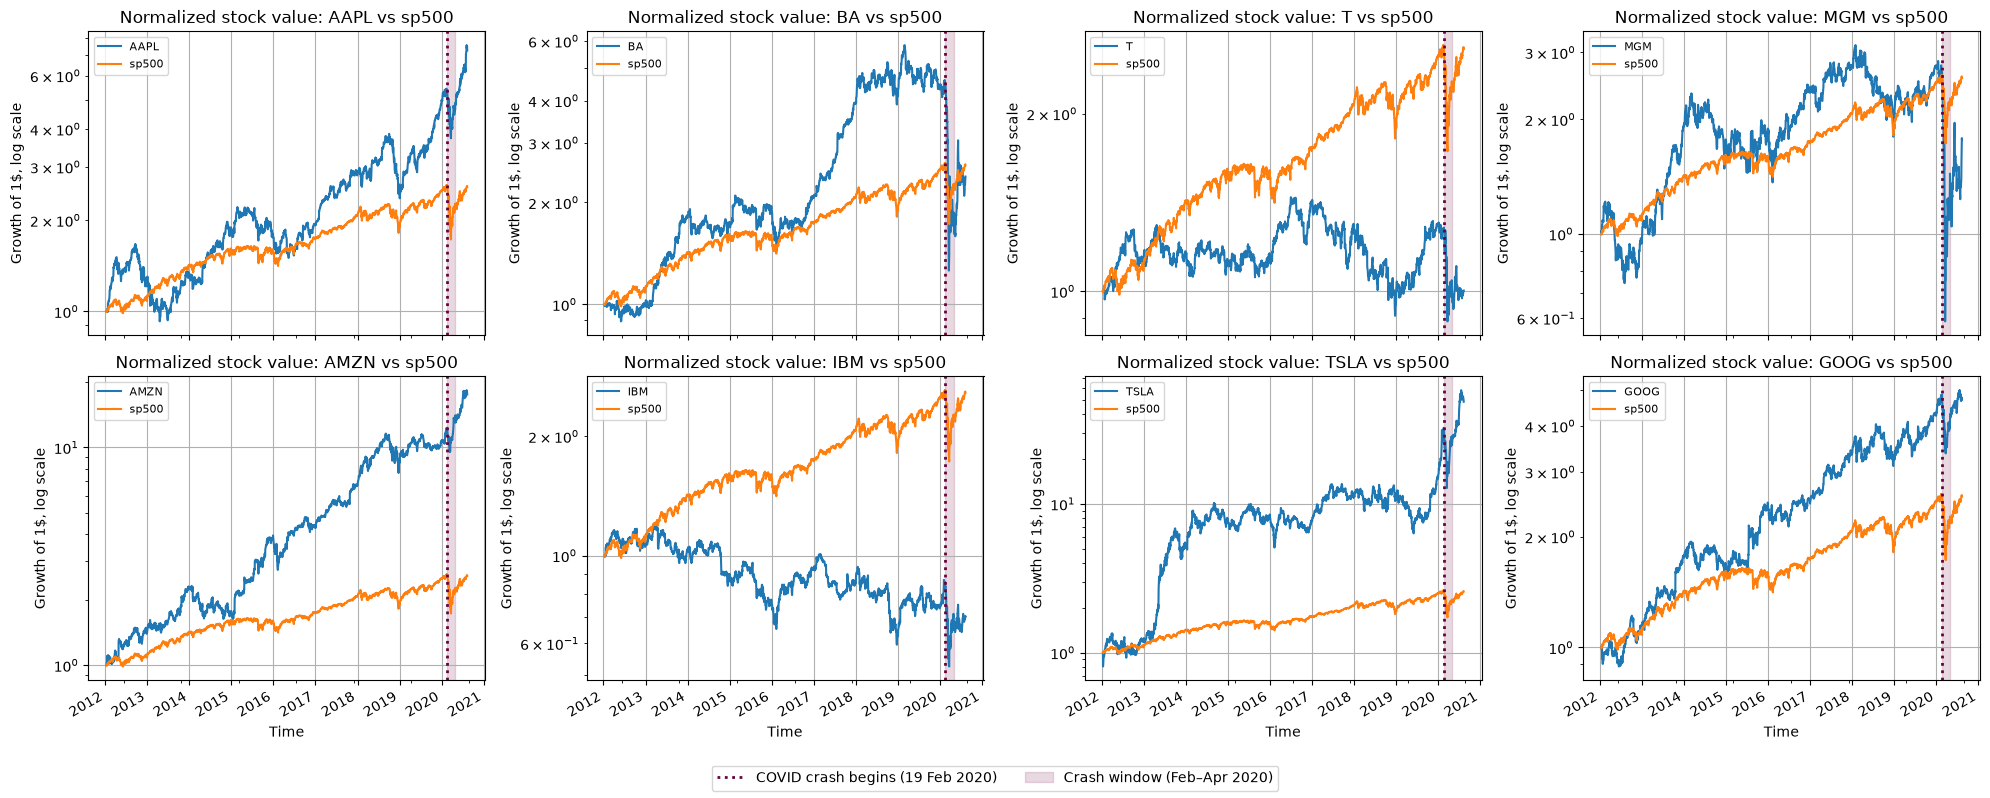

In [7]:
normalized_df = normalize(course_data)

# One panel per stock: growth of $1 for the stock and the S&P 500 (log scale)
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True)

for ax, col in zip(axes.flat, STOCKS):
    normalized_df.plot(x="Date", y=[col, "sp500"], ax=ax, grid=True,
                       title=f"Normalized stock value: {col} vs sp500")
    ax.set_yscale("log")
    ax.set_xlabel("Time")
    ax.set_ylabel("Growth of 1$, log scale")
    ax.axvline(COVID_START, color="#66023C", linestyle=":", linewidth=2)   # COVID crash begins
    ax.axvspan(COVID_START, COVID_END, color="#66023C", alpha=0.15)        # crash window
    ax.legend(loc="upper left", fontsize=8)

# One legend for the COVID markers, shared by all panels
fig.legend(handles=[
    Line2D([0], [0], color="#66023C", linestyle=":", linewidth=2, label="COVID crash begins (19 Feb 2020)"),
    plt.Rectangle((0, 0), 1, 1, color="#66023C", alpha=0.15, label="Crash window (Feb–Apr 2020)"),
], loc="lower center", ncol=2)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Normalized prices (growth of $1, log scale) show that, although all eight stocks are positively correlated with the market, their long-run performance differs widely. TSLA, AMZN, AAPL and GOOG strongly outperform the S&P 500, while T, IBM and MGM underperform; IBM even ends below its starting value.

This matters for the CAPM: IBM and AMZN have almost the same beta (0.96 and 0.99) but opposite outcomes, so beta alone does not explain long-run returns; the gap is firm-specific (alpha/idiosyncratic).

The COVID crash hits all stocks at the same time, consistent with correlations rising in crises, but recoveries diverge: tech stocks quickly recover to new highs, while travel and leisure stocks (BA, MGM) remain well below their pre-crisis levels. BA was already falling before COVID, following the 737 MAX grounding.

### 3.3 Rolling correlation with the market

To check whether the relationship with the market is stable over time, we compute a rolling correlation with the S&P 500 over a 63-day window (about one trading quarter).

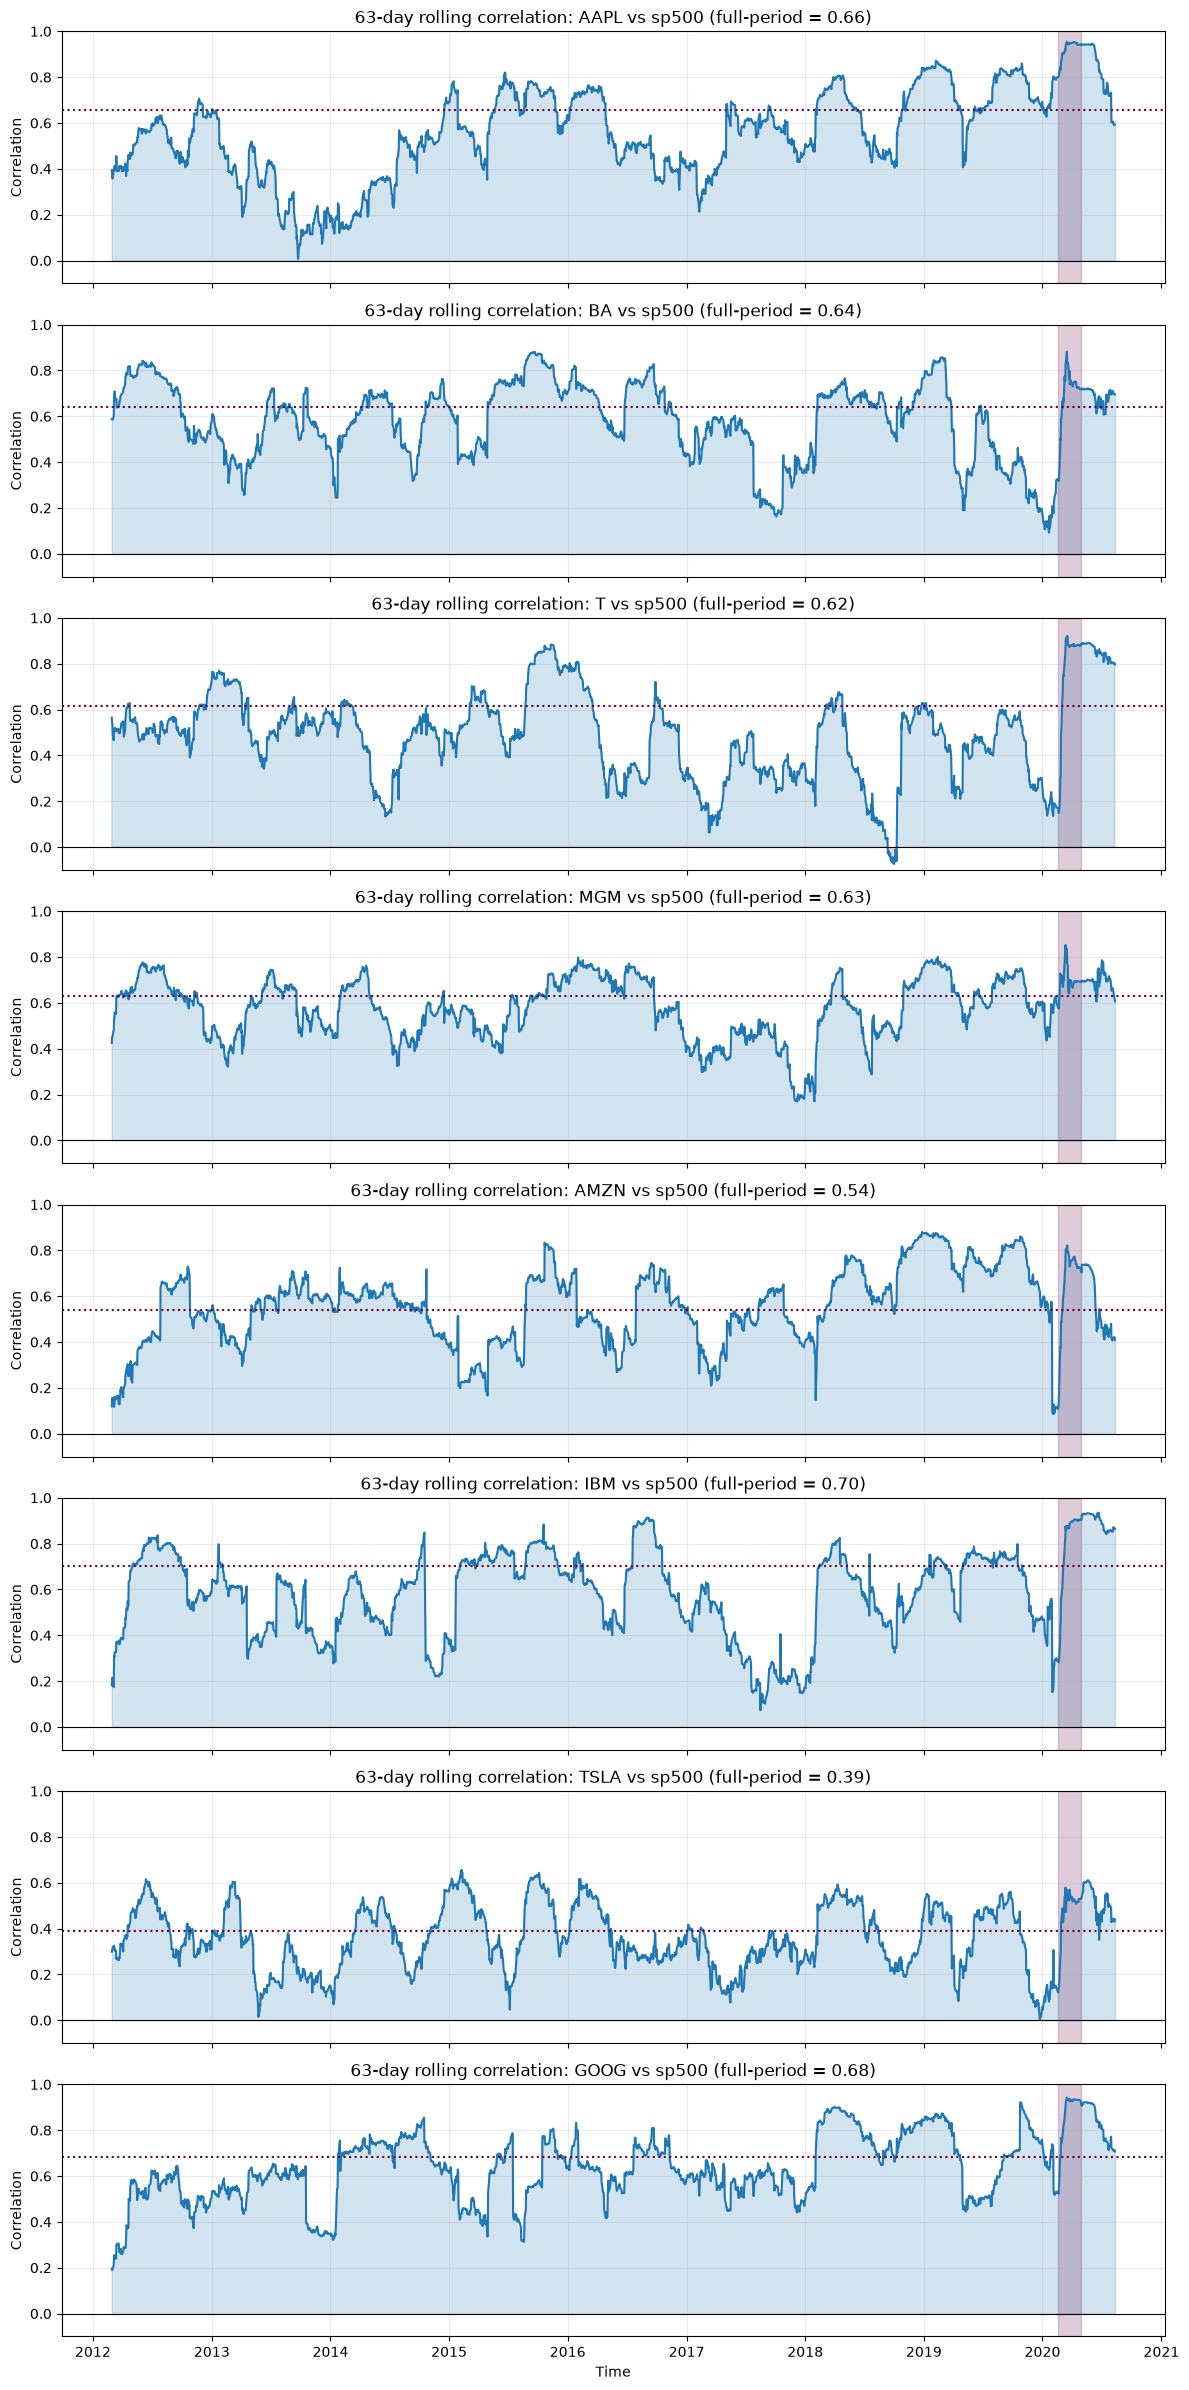

In [8]:
pairs = [ (col, 'sp500') for col in STOCKS]
corr_window = CORR_WINDOW   # about one trading quarter
dates = course_returns["Date"]

fig, axes = plt.subplots( #create one plot per pair
    len(pairs), 1,
    figsize=(12, 3 * len(pairs)),
    sharex=True,
)

#essentially computes correlation based on data in the window ("how correlated were they in the past 3 months?")
for ax, (asset1, asset2) in zip(axes, pairs):
    rolling_corr = (course_returns[asset1].rolling(window=corr_window, min_periods=corr_window // 2).corr(course_returns[asset2]))

    ax.plot(dates, rolling_corr, linewidth=1.5)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.fill_between(dates, 0, rolling_corr, where=rolling_corr >= 0, alpha=0.20, color="tab:blue")
    ax.fill_between(dates, 0, rolling_corr, where=rolling_corr < 0, alpha=0.20, color="tab:red")

    #full-period correlation for reference, and the COVID crash window
    full_corr = course_returns[asset1].corr(course_returns[asset2])
    ax.axhline(full_corr, color="#66023C", linestyle=":", linewidth=1.5)
    ax.axvspan(COVID_START, COVID_END, color="#66023C", alpha=0.2)

    ax.set_title(f"{corr_window}-day rolling correlation: {asset1} vs {asset2} (full-period = {full_corr:.2f})")  #full-period value added to title
    ax.set_ylabel("Correlation")
    ax.set_ylim(-0.1, 1)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Time")
plt.tight_layout()
save_fig("02_rolling_correlation_63d")
plt.show()

The 63-day rolling correlations show that the link between each stock and the S&P 500 is not stable: correlations fluctuate widely over time, so the full-period value only summarizes a changing relationship.

During the COVID crash, correlations jump sharply for almost all stocks, often to their highest levels in the sample, when the market crashes, stocks fall together and diversification benefits shrink.

Conversely, firm-specific events lower correlation: BA's correlation drops through 2019 during the 737 MAX crisis, and T briefly turns negative in late 2018. TSLA remains the least correlated stock throughout (0.39 over the full period). Since beta depends on this correlation, these variations suggest that beta is also time-varying, which we test in Section 5.

## 4. Full-sample CAPM estimation

**Research questions.**
1. For each stock, estimate the CAPM by OLS over the whole period, assuming $r_f = 0$:
$$r_{i,t} - r_f = \alpha_i + \beta_i \,(r_{M,t} - r_f) + \varepsilon_{i,t}.$$
Are the estimates of $\alpha_i$ and $\beta_i$ significant?
2. Which stocks have the highest and lowest beta and alpha?
3. How are the error terms $\varepsilon_{i,t}$ (observed minus CAPM-predicted returns) distributed, and do they satisfy the OLS assumptions?
4. An investor who wants high risk and high return forms an equally weighted portfolio of the four riskiest stocks. What return does the CAPM predict for it, given the estimated $\beta$ and the average market return, and how does that compare with what it actually earned?

### 4.1 OLS estimates

In [9]:
def capm_regression(stock_ret, market_ret, rf=RF, cov_type="nonrobust", hac_lags=HAC_LAGS):
    """CAPM regression of the stock's excess return on the market's excess return"""
    y = stock_ret - rf
    X = sm.add_constant(market_ret - rf)
    if cov_type == "HAC":
        model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
    else:
        model = sm.OLS(y, X).fit(cov_type=cov_type)
    result = {"alpha": model.params.iloc[0], "beta": model.params.iloc[1],
              "se_alpha": model.bse.iloc[0], "se_beta": model.bse.iloc[1],
              "p_alpha": model.pvalues.iloc[0], "p_beta": model.pvalues.iloc[1], "r2": model.rsquared}
    return result, model.resid


def run_capm(returns, stocks, rf=RF, cov_type="nonrobust", hac_lags=HAC_LAGS):
    """One CAPM regression per stock"""
    results, residuals = [], {}
    for stock in stocks:
        res, resid = capm_regression(returns[stock], returns["sp500"], rf=rf, cov_type=cov_type, hac_lags=hac_lags)
        results.append({"stock": stock, **res})
        residuals[stock] = resid
    return pd.DataFrame(results), pd.DataFrame(residuals)


capm, residual_df = run_capm(course_returns, STOCKS)
capm

,stock,alpha,beta,se_alpha,se_beta,p_alpha,p_beta,r2
0,AAPL,0.000528,1.112891,0.000289,0.027479,0.067202,3.521164e-267,0.432070
1,BA,-0.000023,1.382867,0.000374,0.035584,0.951096,7.299279e-251,0.411941
2,T,-0.000286,0.744630,0.000215,0.020430,0.182942,4.892378e-227,0.381261
3,MGM,-0.000169,1.653568,0.000459,0.043732,0.712986,1.874186e-240,0.398728
4,AMZN,0.001023,0.991732,0.000350,0.033328,0.003512,2.611172e-163,0.291125
5,IBM,-0.000535,0.960416,0.000219,0.020870,0.014747,0.000000e+00,0.495525
6,TSLA,0.001759,1.268611,0.000682,0.064916,0.009920,1.965135e-78,0.150482
7,GOOG,0.000334,1.034881,0.000249,0.023732,0.180655,2.345742e-298,0.468638


All betas are highly significant (all significantly different from zero). MGM has the highest beta (1.65), followed by BA (1.38) and TSLA (1.27), while T is the most defensive (0.74); AMZN, IBM and GOOG move roughly one-for-one with the market.

The CAPM predicts α = 0: this holds for five stocks, but TSLA and AMZN have significantly positive alphas (≈ +44% and +26% per year) and IBM a significantly negative one (≈ −13%), consistent with their cumulative performance. These alphas reflect realized, past performance and do not imply they can be earned in the future.

R² ranges from 0.15 (TSLA) to 0.50 (IBM): the market explains at most half of daily return variance. Classic OLS standard errors assume homoskedastic and uncorrelated residuals, we test these assumptions below and re-estimate significance with HAC standard errors.

### 4.2 Residual diagnostics

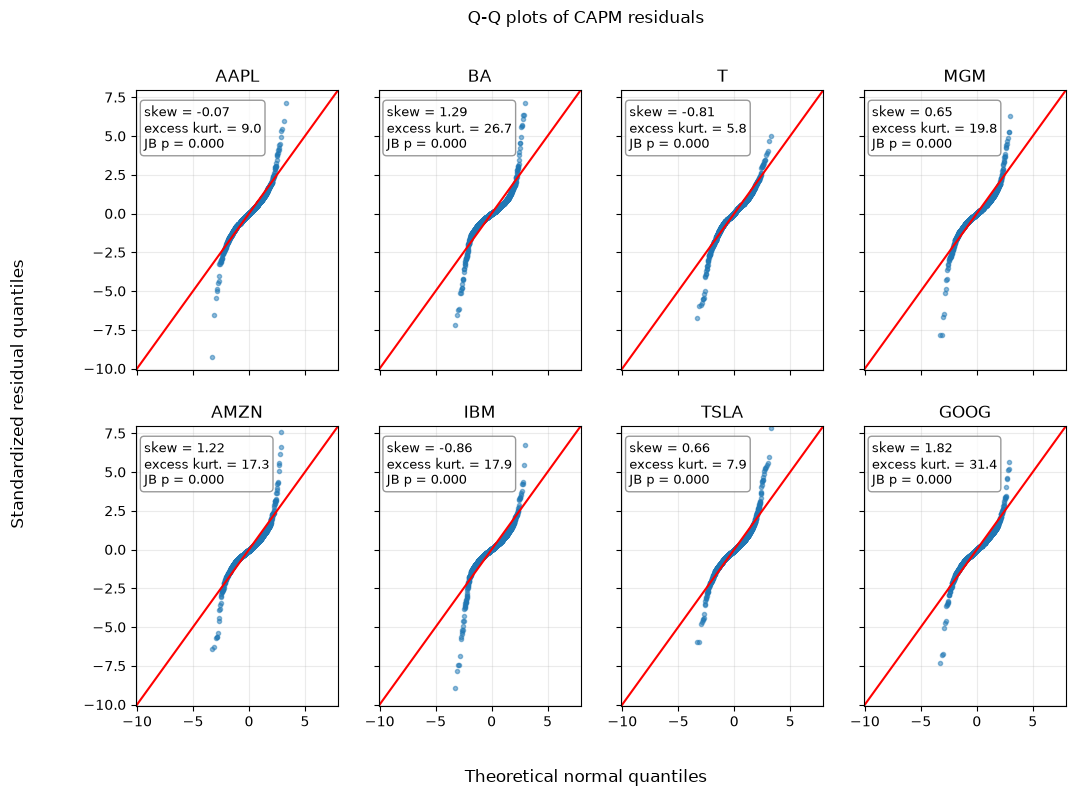

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8), sharex=True, sharey=True)

for stock, ax in zip(STOCKS, axes.flat):
    res = residual_df[stock].dropna()
    sm.qqplot(res, line="45", fit=True, ax=ax, markersize=3, alpha=0.5)   # standardize the residuals
    ax.grid(alpha=0.25)

    # numbers that quantify the departure from normality
    sk, ku, jb_p = skew(res), kurtosis(res), jarque_bera(res).pvalue
    ax.set_title(stock)
    ax.text(0.04, 0.95, f"skew = {sk:.2f}\nexcess kurt. = {ku:.1f}\nJB p = {jb_p:.3f}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="gray"))
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.supxlabel("Theoretical normal quantiles")
fig.supylabel("Standardized residual quantiles")
fig.suptitle("Q-Q plots of CAPM residuals")
save_fig("03_residual_qq_plots")
plt.show()

The Q–Q plots show that the CAPM residuals deviate from the normal distribution in both tails: negative residuals fall below the reference line and positive residuals rise above it. The residual distribution therefore has heavier tails than a normal distribution, meaning extreme unexplained returns occur more often than normality would predict. The Jarque–Bera test rejects normality for every stock (p < 0.001), with excess kurtosis ranging from 5.8 (T) to 31.4 (GOOG), compared with 0 for a normal distribution; skewness is negative for T and IBM and positive for most other stocks.

This is not a major problem for our estimates. Normality is not required for the OLS coefficients to be unbiased, and with more than 2,000 daily observations the t-tests remain asymptotically valid. What matters for the standard errors is whether the residuals are homoskedastic and uncorrelated, which we test below.

In [11]:
def residual_diagnostics(stock_ret, market_ret, lags=BG_LAGS):
    """p-values of the tests on CAPM residuals (H0: no problem)"""
    X = sm.add_constant(market_ret)
    model = sm.OLS(stock_ret, X).fit()
    return {
        "Breusch-Pagan (hetero.)":    het_breuschpagan(model.resid, X)[1],   # e^2 regressed on r_m
        "White (hetero.)":            het_white(model.resid, X)[1],          # e^2 regressed on r_m and r_m^2
        # result_object=False keeps the current tuple output and silences a statsmodels FutureWarning
        "Breusch-Godfrey (autocorr.)": acorr_breusch_godfrey(model, nlags=lags, result_object=False)[1],
    }

diagnostics = pd.DataFrame(
    {stock: residual_diagnostics(course_returns[stock], course_returns["sp500"]) for stock in STOCKS}
).T

# Bold = H0 rejected at 5%
display(diagnostics.style.format("{:.3f}")
        .map(lambda p: "font-weight: bold; color: #c00000" if p < 0.05 else ""))

,Breusch-Pagan (hetero.),White (hetero.),Breusch-Godfrey (autocorr.)
AAPL,0.839,0.860,0.217
BA,0.027,0.000,0.000
T,1.000,0.000,0.277
MGM,0.023,0.000,0.000
AMZN,0.504,0.000,0.011
IBM,0.693,0.000,0.010
TSLA,0.016,0.000,0.146
GOOG,0.516,0.596,0.057


The table reports the p-values of three tests on the CAPM residuals (null hypothesis: no problem; bold red = rejected at 5%).

The Breusch–Pagan test regresses the squared residuals on $r_M$ and only detects a variance that changes linearly with the market return; it rejects homoskedasticity for BA, MGM and TSLA. The White test is more general: its auxiliary regression includes the regressors, their squares and cross-products, which with a single regressor reduces to $r_M$ and $r_M^2$. It rejects for six of the eight stocks (all except AAPL and GOOG), suggesting that residuals are larger on days with large market moves in either direction, such as the COVID crash. Because of the squared term, a White rejection can also signal a misspecified model (for example a non-linear relation with the market) rather than pure heteroskedasticity.

The **Breusch–Godfrey** test finds autocorrelation up to five lags for BA, MGM, AMZN and IBM, with GOOG borderline (p = 0.057).

The homoskedasticity and no-autocorrelation assumptions therefore do not hold for most stocks. The OLS estimates of α and β remain unbiased, but the classic standard errors are unreliable, so we re-estimate them with HAC (Newey–West) standard errors, which are robust to both heteroskedasticity and autocorrelation.

In [12]:
capm_hac_df, residual_df_hac = run_capm(course_returns, STOCKS, cov_type="HAC", hac_lags=HAC_LAGS)
capm_hac_df

,stock,alpha,beta,se_alpha,se_beta,p_alpha,p_beta,r2
0,AAPL,0.000528,1.112891,0.000299,0.031527,0.077062,6.007015e-273,0.432070
1,BA,-0.000023,1.382867,0.000410,0.080792,0.955419,1.118909e-65,0.411941
2,T,-0.000286,0.744630,0.000214,0.030770,0.182454,2.241467e-129,0.381261
3,MGM,-0.000169,1.653568,0.000467,0.075339,0.717634,9.001635e-107,0.398728
4,AMZN,0.001023,0.991732,0.000346,0.088243,0.003150,2.634282e-29,0.291125
5,IBM,-0.000535,0.960416,0.000216,0.031633,0.013226,1.761830e-202,0.495525
6,TSLA,0.001759,1.268611,0.000672,0.085539,0.008877,9.269982e-50,0.150482
7,GOOG,0.000334,1.034881,0.000240,0.038405,0.165133,6.303250e-160,0.468638


Re-estimating with HAC standard errors leaves α, β and R² unchanged, since only the measure of uncertainty is affected. The standard errors of beta increase noticeably, more than doubling for BA (0.036 → 0.081) and AMZN (0.033 → 0.088): plain OLS overstated the precision of beta, especially for the most volatile stocks. However, no conclusion changes. All betas remain highly significant, and TSLA, AMZN and IBM still show significant alphas at the 5% level, while AAPL's is significant only at 10%. Our results are therefore robust to heteroskedasticity and autocorrelation in the residuals.

### 4.3 Beta, alpha and R² with HAC standard errors

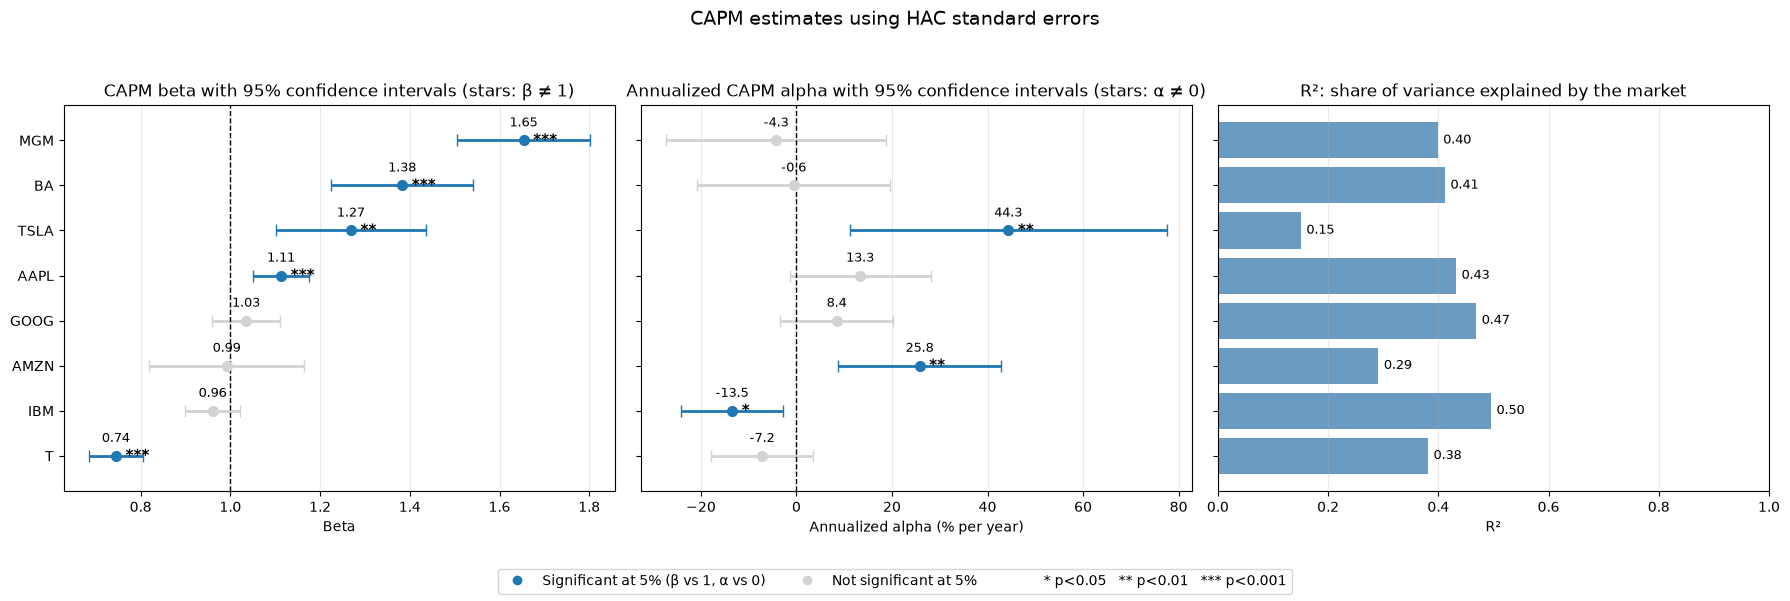

In [13]:
# Sort stocks from highest to lowest beta (index reset so positions go 0..7)
plot_df = capm_hac_df.sort_values("beta", ascending=False).reset_index(drop=True)   #HAC results, sorted by beta

# test beta against 1 (the null line in the plot)
# z = (beta - 1) / se  ->  two-sided p-value from the normal distribution
plot_df["p_beta_vs1"] = 2 * norm.sf(np.abs((plot_df["beta"] - 1) / plot_df["se_beta"]))

# Convert a p-value into significance stars
def significance_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

# Reusable plot: each estimate with its 95% confidence interval (blue = significant, gray = not)
def coefficient_plot(ax, estimates, standard_errors, p_values, labels, null_value, title, xlabel,
                     value_format="{:.2f}"):
    y_positions = np.arange(len(labels))   # one row per stock

    for y, estimate, se, p_value in zip(y_positions, estimates, standard_errors, p_values):
        significant = p_value < 0.05
        color = "tab:blue" if significant else "lightgray"

        # Point estimate and 95% confidence interval
        # (dot = estimate, horizontal bar = estimate ± 1.96 × standard error)
        ax.errorbar(estimate, y, xerr=1.96 * se, fmt="o", color=color, ecolor=color, capsize=4, markersize=7, linewidth=2)
        # Stars written just to the right of the dot
        ax.annotate(significance_stars(p_value), (estimate, y), xytext=(7, 0), textcoords="offset points", va="center",
                    fontsize=11, fontweight="bold")
        ax.annotate(value_format.format(estimate), (estimate, y), xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=9)                          # estimate written above each point

    # Reference line (1 for beta, 0 for alpha): if an interval crosses it, the difference is not significant
    ax.axvline(null_value, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)          # stock names on the y-axis
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(axis="x", alpha=0.25)


# Three side-by-side panels sharing the same y-axis (same stock order)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Beta: test whether beta differs from 1 which is the market risk
coefficient_plot(ax=axes[0], estimates=plot_df["beta"], standard_errors=plot_df["se_beta"], p_values=plot_df["p_beta_vs1"],
    labels=plot_df["stock"], null_value=1, title="CAPM beta with 95% confidence intervals (stars: β ≠ 1)", xlabel="Beta")

# daily alpha converted to annualized % (x252)
# (standard errors scaled the same way; p-values unchanged; CAPM predicts alpha = 0)
coefficient_plot(ax=axes[1], estimates=plot_df["alpha"] * TRADING_DAYS * 100, standard_errors=plot_df["se_alpha"] * TRADING_DAYS * 100,
    p_values=plot_df["p_alpha"], labels=plot_df["stock"], null_value=0, title="Annualized CAPM alpha with 95% confidence intervals (stars: α ≠ 0)",
    xlabel="Annualized alpha (% per year)", value_format="{:.1f}")

# R² panel = share of each stock's variance explained by the market
axes[2].barh(np.arange(len(plot_df)), plot_df["r2"], color="steelblue", alpha=0.8)
for y, r2 in enumerate(plot_df["r2"]):
    axes[2].text(r2 + 0.01, y, f"{r2:.2f}", va="center", fontsize=9)   # value written next to each bar
axes[2].set_xlim(0, 1)
axes[2].set_title("R²: share of variance explained by the market")
axes[2].set_xlabel("R²")
axes[2].grid(axis="x", alpha=0.25)

axes[0].invert_yaxis() # show the highest beta at the top (applies to all panels via sharey)

# Legend explaining the colors
legend_items = [Line2D([0], [0], marker="o", color="tab:blue", linestyle="", label="Significant at 5% (β vs 1, α vs 0)"),
    Line2D([0], [0], marker="o", color="lightgray", linestyle="", label="Not significant at 5%"),
    Line2D([0], [0], linestyle="", label="* p<0.05   ** p<0.01   *** p<0.001")]   # explains the stars

fig.legend(handles=legend_items, loc="lower center", ncol=3)
fig.suptitle("CAPM estimates using HAC standard errors", fontsize=14)


# Leave space at the bottom for the legend and at the top for the title
plt.tight_layout(rect=[0, 0.08, 1, 0.94])
save_fig("04_capm_beta_alpha_r2_hac")
plt.show()

**Beta**: Four stocks are significantly riskier than the market (β > 1): MGM (1.65), BA (1.38), TSLA (1.27) and AAPL (1.11). T is the only significantly defensive stock (0.74), while GOOG, AMZN and IBM are statistically indistinguishable from the market (β ≈ 1).

**Alpha**: For five of the eight stocks, alpha is not significantly different from zero, as the CAPM predicts. The exceptions are TSLA (+44.3% per year) and AMZN (+25.8%), which earned significantly more than their market risk justifies, and IBM (−13.5%), which earned significantly less. These alphas reflect realized past performance, not a return an investor could expect to earn going forward. Alpha confidence intervals are also very wide compared with those of beta: market risk is estimated precisely, but average returns are not.

**R²**: The market explains between 15% (TSLA) and 50% (IBM) of daily variance. Even in the best case, half of a stock's risk is firm-specific and could be diversified away.

Part of IBM's significantly negative alpha, and of T's negative but insignificant one, may be mechanical: these are the two highest dividend payers in the sample, and the course prices do not include dividends (see the note on returns in Section 2).

### 4.4 Distribution of the residuals

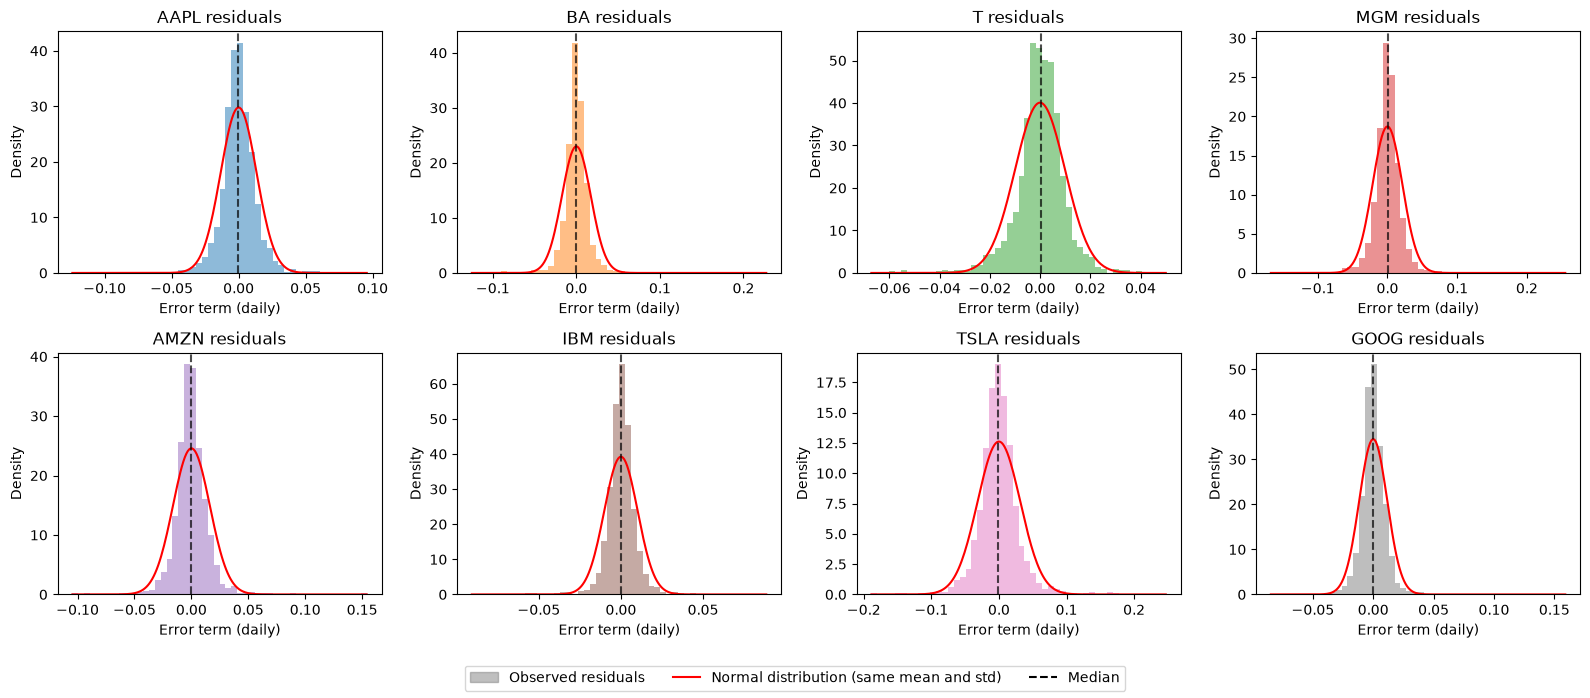

In [14]:
plt.figure(figsize=(16, 7))

for i, stock in enumerate(STOCKS):
    alpha = capm.loc[i, "alpha"]
    beta = capm.loc[i, "beta"]

    predicted = alpha + beta * course_returns["sp500"]      # CAPM predicted return
    residuals = course_returns[stock] - predicted           # observed - predicted

    plt.subplot(2, 4, i + 1)
    plt.hist(residuals, bins=50, density=True, color=f"C{i}", alpha = 0.5)

    # Normal distribution with the same mean and std as the residuals
    grid = np.linspace(residuals.min(), residuals.max(), 200)
    plt.plot(grid, norm.pdf(grid, residuals.mean(), residuals.std()), color="red")

    plt.axvline(residuals.median(), color="black", linestyle="--", linewidth=1.5, alpha = 0.7)   #median line

    plt.title(stock + " residuals")
    plt.xlabel("Error term (daily)")
    plt.ylabel("Density")

#one legend for the whole figure
plt.figlegend(handles=[
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.5, label="Observed residuals"),
    Line2D([0], [0], color="red", label="Normal distribution (same mean and std)"),
    Line2D([0], [0], color="black", linestyle="--", label="Median"),
], loc="lower center", ncol=3)

plt.tight_layout(rect=[0, 0.06, 1, 1])
save_fig("05_residual_histograms")
plt.show()

The residuals of all eight stocks are centered on zero, with the median almost exactly at zero. This is partly mechanical, since OLS residuals have mean zero by construction, but it also shows the CAPM line is not systematically biased on a typical day. Compared with the fitted normal curve, every histogram has a taller, narrower peak and long tails: most days the CAPM prediction is very close, but on a few days the error is far larger than a normal distribution would allow. This confirms the fat tails found in the Q–Q plots. The spread of the errors also differs widely across stocks: it is largest for TSLA and smallest for T. TSLA's wide spread matches its low R²: much of its risk is firm-specific and not explained by the market, and it is precisely this idiosyncratic risk that diversification can eliminate.

### 4.5 Rolling betas

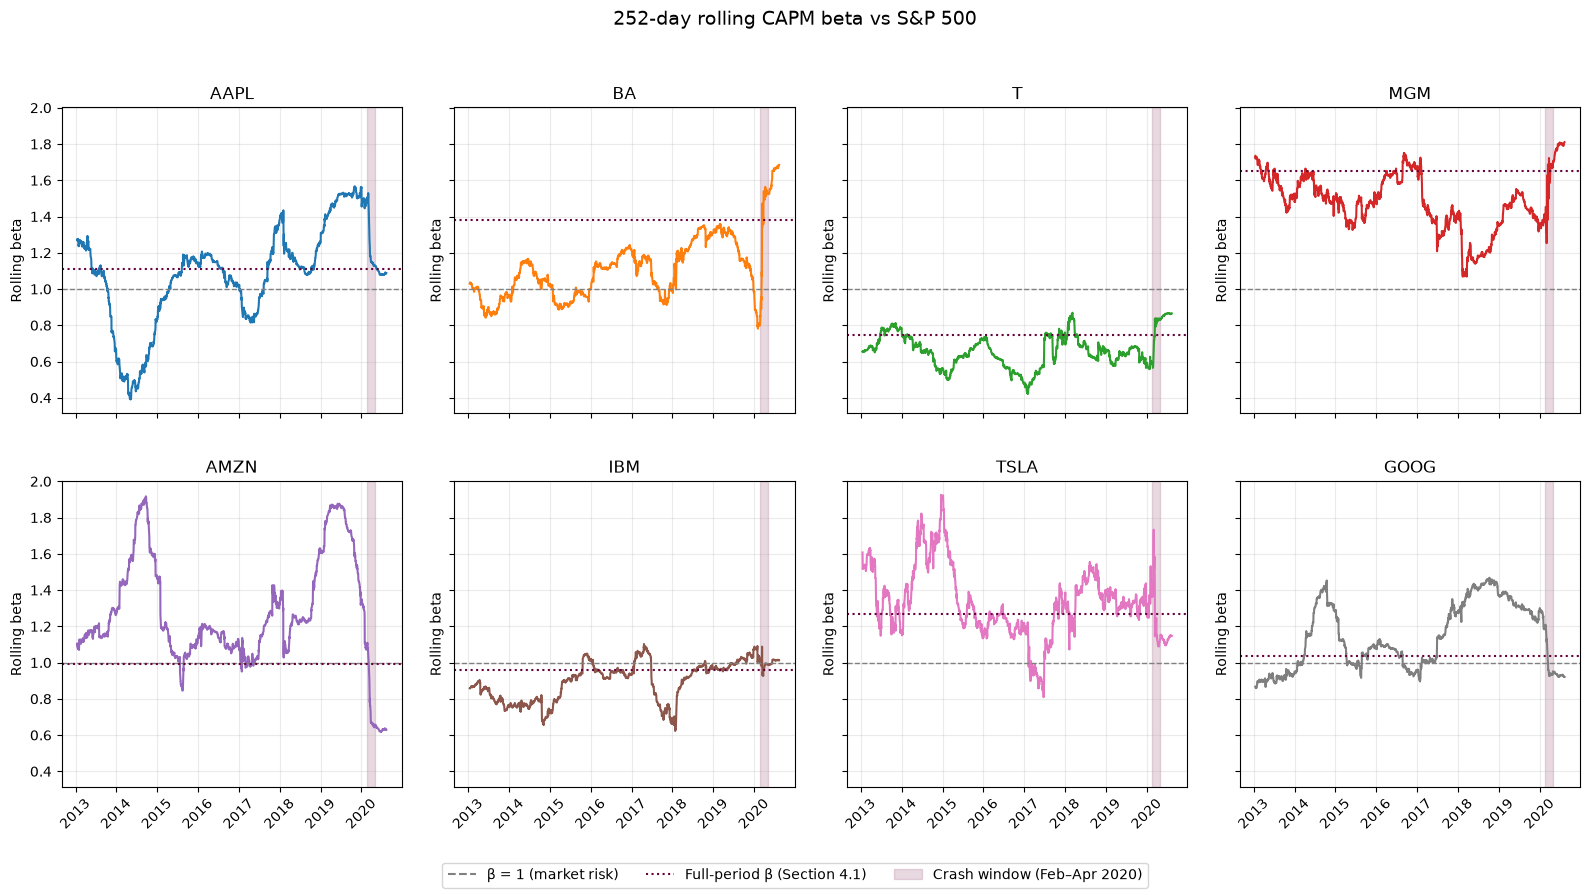

In [15]:
# Rolling 252-day beta of each stock vs the S&P 500
beta_window = BETA_WINDOW                                             # one trading year, same as Section 5

rets = course_returns.set_index("Date")

fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)

for i, (stock, ax) in enumerate(zip(STOCKS, axes.flat)):
    # beta = cov(stock, market) / var(market), computed on a rolling window (= OLS slope)
    rolling_beta = (
        rets[stock].rolling(beta_window).cov(rets["sp500"])
        / rets["sp500"].rolling(beta_window).var()
    )
    full_beta = capm.loc[capm["stock"] == stock, "beta"].iloc[0]   # full-period beta from Section 4.1

    ax.plot(rolling_beta.index, rolling_beta, color=f"C{i}", linewidth=1.5)
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)                       # beta = 1: same risk as market
    ax.axhline(full_beta, color="#66023C", linestyle=":", linewidth=1.5)           # full-period beta (Section 4.1)
    ax.axvspan(COVID_START, COVID_END, color="#66023C", alpha=0.15)                    # crash window

    ax.set_title(stock)
    ax.set_ylabel("Rolling beta")
    ax.grid(alpha=0.25)
    ax.tick_params(axis="x", rotation=45)

legend_items = [
    Line2D([0], [0], color="gray", linestyle="--", label="β = 1 (market risk)"),
    Line2D([0], [0], color="#66023C", linestyle=":", linewidth=1.5, label="Full-period β (Section 4.1)"),
    plt.Rectangle((0, 0), 1, 1, color="#66023C", alpha=0.15, label="Crash window (Feb–Apr 2020)"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=3)
fig.suptitle(f"{beta_window}-day rolling CAPM beta vs S&P 500", fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 0.95], h_pad=3, w_pad=2)
save_fig("06_rolling_beta_252d")
plt.show()

Rolling betas show that a stock's market risk is far from constant. AAPL, AMZN and TSLA swing widely over the period, crossing β = 1 several times, while IBM and T remain comparatively stable. A single full-period beta therefore hides large variations, and a stock can switch from "defensive" to "aggressive" within a couple of years. The COVID crash causes sharp jumps in opposite directions: BA and MGM, whose businesses were directly hit by lockdowns, see their betas jump upward, and T's rises too, while AMZN's falls well below 1 as it held up much better than the market. Because the crash stays inside the 252-day window for a full year, these shifts persist until the end of the sample. This instability suggests that a beta estimated on past data may be a poor guide to future risk, which is exactly what we test in Section 5. (The series start in 2013 because the first year of data is needed to fill the window.)

### 4.6 High-risk portfolio: the four highest-beta stocks, equally weighted

In [16]:
capm_portfolio_tickers = capm.sort_values("beta", ascending=False).head(4)["stock"]
print("Portfolio tickers:", list(capm_portfolio_tickers))

# Portfolio beta = average of the 4 betas (equal weights)
beta_p = capm[capm["stock"].isin(capm_portfolio_tickers)]["beta"].mean()

# CAPM expected return (rf = 0): beta_p x average market return
expected_p = RF + beta_p * (course_returns["sp500"].mean() - RF)

# Realized return of the equally weighted portfolio
daily_portfolio_returns = course_returns[capm_portfolio_tickers].mean(axis=1) #daily return of the portfolio (equal weights)
realized_p = daily_portfolio_returns.mean()

print("Portfolio beta:", round(beta_p, ndigits=2))
print("CAPM expected return (annualized):", round(expected_p * TRADING_DAYS, ndigits=3))   # 252 trading days by convention
print("Realized return (annualized):     ", round(realized_p * TRADING_DAYS, ndigits=3))

Portfolio tickers: ['MGM', 'BA', 'TSLA', 'AAPL']
Portfolio beta: 1.35
CAPM expected return (annualized): 0.168
Realized return (annualized):      0.3


The four highest-beta stocks are MGM, BA, TSLA and AAPL, giving an equally weighted portfolio with β = 1.35. The CAPM predicts an annualized return of 16.8%, but the portfolio actually earned 30.0%, about 13 percentage points more. This gap equals the average alpha of the four stocks and comes mainly from TSLA, the only one with a significant alpha; MGM and BA contributed almost nothing beyond their market exposure. In other words, the extra return did not come from taking more market risk, as the CAPM would suggest, but from one stock's exceptional past performance, which is unlikely to be repeatable. It should also be kept in mind that with β = 1.35, the portfolio would fall on average about 1.35 times as much as the market in a downturn.

Two further remarks on the investor's request. First, we define "riskier" by beta, i.e. systematic risk, because that is the only risk the CAPM rewards. Ranking by total volatility could change the selection (TSLA would rank first), but the extra idiosyncratic risk would not raise the portfolio's CAPM-expected return. Second, a four-stock portfolio keeps a large amount of idiosyncratic risk, which the CAPM says is not compensated. If the goal is to take more *rewarded* risk, the CAPM's answer is to hold the diversified market portfolio with leverage (β > 1) rather than to concentrate in a few stocks.

## 5. Predictive test: prior-year beta vs. realized returns

**Research questions.**
1. If we estimate each stock's beta over the year before year $y$, does $\beta_i^{y-1}$ combined with the market return realized in year $y$ predict the stock's realized return in $y$?
2. Is the relation between prior-year beta and realized return (the security market line) as steep as the CAPM implies, year by year?
3. How stable is beta, and does the length of the estimation window (shorter or longer than one year) change the results?
4. What is the economic interpretation of the results?

### 5.1 Method and data

**Method.** For each evaluation year $y$:

1. estimate $\beta_i^{y-1}$ by OLS on the last 252 trading days before 1 January of year $y$;
2. compute the stock's average daily return in year $y$ and annualize it ($\times 252$);
3. compute the CAPM prediction using that beta and the market's average return realized in year $y$.

Using the beta from $y-1$ but the market return from $y$ isolates the question the CAPM actually answers: given what the market did, did stocks with a higher (ex ante) beta earn proportionally more?

In [17]:
def split_yearly_periods(returns, window=BETA_WINDOW):
    """For each year y: the `window` trading days before y (to estimate beta) and the days of y (to evaluate)"""
    data = returns.set_index("Date")
    periods = {}
    for year in sorted(data.index.year.unique()):
        beta_period = data.loc[data.index < f"{year}-01-01"].tail(window)
        evaluation_period = data.loc[data.index.year == year]
        if len(beta_period) < window or evaluation_period.empty:    # not enough history, or no data in y
            continue
        periods[year] = {"beta_period": beta_period, "evaluation_period": evaluation_period}
    return periods

def rolling_capm(returns, window=BETA_WINDOW):
    """One CAPM per stock and per year, beta estimated on the `window` days before the evaluation year"""
    rows = []
    for year, period in split_yearly_periods(returns, window=window).items():
        for stock in STOCKS:
            reg_data = period["beta_period"][[stock, "sp500"]].dropna()
            if len(reg_data) < window:
                continue
            res, _ = capm_regression(reg_data[stock], reg_data["sp500"])
            rows.append({"stock": stock, "evaluation_year": year, "window": window, **res})
    return pd.DataFrame(rows)


periods = split_yearly_periods(course_returns)
capm_by_period = rolling_capm(course_returns, window=BETA_WINDOW)
capm_by_period.head()

,stock,evaluation_year,window,alpha,beta,se_alpha,se_beta,p_alpha,p_beta,r2
0,AAPL,2014,252,-0.000287,0.626566,0.001114,0.158253,0.796893,9.805888e-05,0.059003
1,BA,2014,252,0.001430,0.966673,0.000737,0.104702,0.053437,1.168838e-17,0.254269
2,T,2014,252,-0.000611,0.784543,0.000521,0.074071,0.242126,6.752284e-22,0.309745
3,MGM,2014,252,0.001356,1.526288,0.000958,0.136145,0.158376,6.715149e-24,0.334542
4,AMZN,2014,252,0.000651,1.265466,0.000929,0.132027,0.484152,9.842293e-19,0.268729


Formally, with $r_f = 0$, we compare the realized annualized return $\bar r_i^{\,y}$ with the CAPM prediction $\hat r_i^{\,y} = \beta_i^{y-1} \times \bar r_M^{\,y}$, and define the prediction error as $\bar r_i^{\,y} - \hat r_i^{\,y}$.

In [18]:
# Annualized average return of each stock and of the market in each evaluation year
annualized_returns = pd.DataFrame({
    year: period["evaluation_period"][
        STOCKS + ["sp500"]
    ].mean() * TRADING_DAYS # average daily return x trading days per year
    for year, period in periods.items()
}).T

annualized_returns.index.name = "evaluation_year"

display(annualized_returns)

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
evaluation_year,,,,,,,,,
2014,0.343711,-0.030139,-0.035257,-0.048195,-0.197648,-0.141403,0.505964,-0.039032,0.114345
2015,-0.011884,0.130017,0.036940,0.135428,0.833698,-0.130693,0.151116,0.410651,0.004678
2016,0.122873,0.103335,0.222860,0.290248,0.147730,0.207081,-0.040560,0.036887,0.099646
2017,0.396499,0.657706,-0.074753,0.178395,0.467804,-0.066717,0.440463,0.317646,0.180474
2018,-0.029376,0.139141,-0.282077,-0.253648,0.316396,-0.269934,0.234861,0.029200,-0.050120
2019,0.656638,0.051926,0.331854,0.350760,0.233466,0.186048,0.350457,0.284456,0.261588
2020,0.782204,-0.422194,-0.329690,-0.039994,0.919402,0.023305,2.400446,0.259907,0.139240


The evaluation years run from 2014 to 2020. 2013 is lost because the course data start on 12 January 2012, which leaves fewer than 252 trading days before 1 January 2013 to estimate a beta. 2020 is a partial year: the data end in the summer of 2020, so the "annualized" 2020 figures scale roughly two-thirds of a year of returns (including both the COVID crash and the rebound) to a full year and should be read with care, most obviously TSLA's +240%.

The market environment varies a lot across years, from −5.0% in 2018 and +0.5% in 2015 to +26.2% in 2019. This variation is useful for the test: in a CAPM world, high-beta stocks should outperform in strong years and underperform in weak ones.

In [19]:
# Reshape annualized returns to long format (one row per stock and year), to merge them with the yearly betas
annualized_long = (annualized_returns.rename_axis("evaluation_year").reset_index().melt(
        id_vars="evaluation_year",
        value_vars=STOCKS,
        var_name="stock",
        value_name="actual_return"))

# Market return for each evaluation year
market_by_year = (annualized_returns["sp500"].rename("market_return").rename_axis("evaluation_year").reset_index())

In [20]:
capm_evaluation = (capm_by_period.merge(annualized_long, on=["evaluation_year", "stock"], how="inner").merge(
        market_by_year, on="evaluation_year", how="inner"))

#assuming again that rf=0
capm_evaluation["predicted_return"] = (
    capm_evaluation["beta"]
    * capm_evaluation["market_return"]
)

capm_evaluation["prediction_error"] = (
    capm_evaluation["actual_return"]
    - capm_evaluation["predicted_return"]
)

capm_evaluation.head()

,stock,evaluation_year,window,alpha,beta,se_alpha,se_beta,p_alpha,p_beta,r2,actual_return,market_return,predicted_return,prediction_error
0,AAPL,2014,252,-0.000287,0.626566,0.001114,0.158253,0.796893,9.805888e-05,0.059003,0.343711,0.114345,0.071644,0.272067
1,BA,2014,252,0.001430,0.966673,0.000737,0.104702,0.053437,1.168838e-17,0.254269,-0.030139,0.114345,0.110534,-0.140673
2,T,2014,252,-0.000611,0.784543,0.000521,0.074071,0.242126,6.752284e-22,0.309745,-0.035257,0.114345,0.089708,-0.124966
3,MGM,2014,252,0.001356,1.526288,0.000958,0.136145,0.158376,6.715149e-24,0.334542,-0.048195,0.114345,0.174523,-0.222718
4,AMZN,2014,252,0.000651,1.265466,0.000929,0.132027,0.484152,9.842293e-19,0.268729,-0.197648,0.114345,0.144699,-0.342347


In [21]:
# Keep only the columns needed to compare predicted and realized returns
result_evaluation = capm_evaluation[
    [
        "evaluation_year",
        "stock",
        "beta",
        "market_return",
        "predicted_return",
        "actual_return",
        "prediction_error",
    ]
]

display(
    result_evaluation.style.format({ #all in percentage
        "beta": "{:.3f}",
        "market_return": "{:.2%}",
        "predicted_return": "{:.2%}",
        "actual_return": "{:.2%}",
        "prediction_error": "{:+.2%}",
    })
)

,evaluation_year,stock,beta,market_return,predicted_return,actual_return,prediction_error
0,2014,AAPL,0.627,11.43%,7.16%,34.37%,+27.21%
1,2014,BA,0.967,11.43%,11.05%,-3.01%,-14.07%
2,2014,T,0.785,11.43%,8.97%,-3.53%,-12.50%
3,2014,MGM,1.526,11.43%,17.45%,-4.82%,-22.27%
4,2014,AMZN,1.265,11.43%,14.47%,-19.76%,-34.23%
5,2014,IBM,0.765,11.43%,8.75%,-14.14%,-22.89%
6,2014,TSLA,1.175,11.43%,13.43%,50.60%,+37.17%
7,2014,GOOG,0.945,11.43%,10.81%,-3.90%,-14.71%
8,2015,AAPL,0.835,0.47%,0.39%,-1.19%,-1.58%
9,2015,BA,1.021,0.47%,0.48%,13.00%,+12.52%


### 5.2 CAPM-predicted vs. realized returns

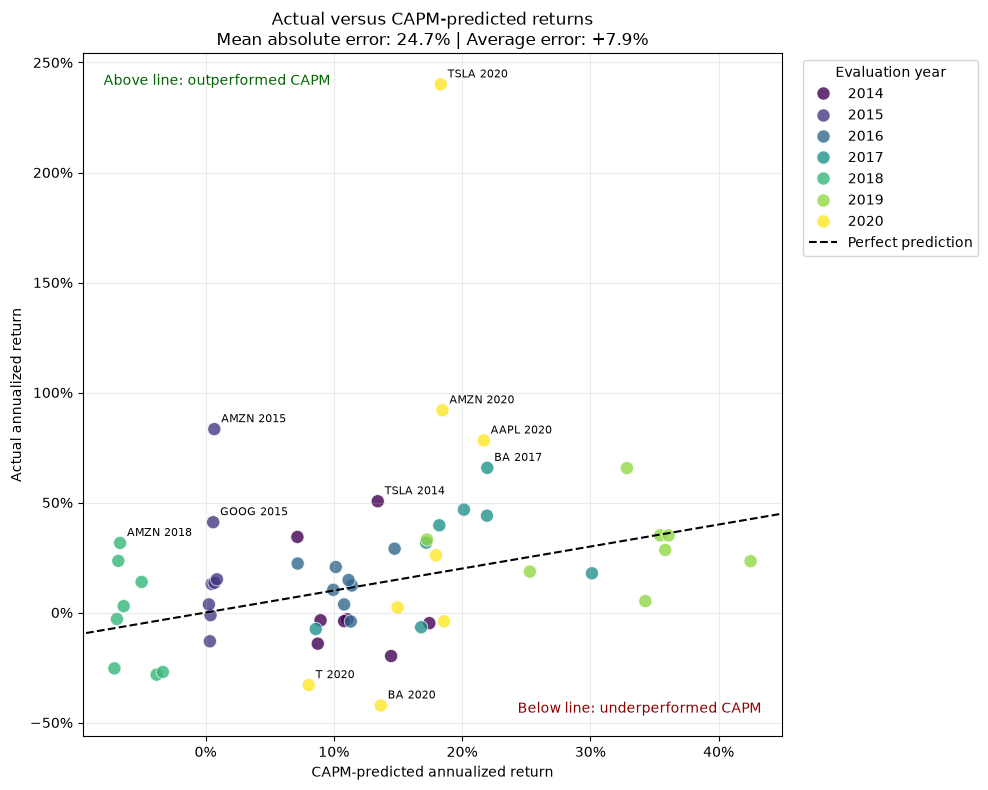

In [22]:
plot_data = (
    capm_evaluation[
        [
            "stock",
            "evaluation_year",
            "actual_return",
            "predicted_return",
            "prediction_error",
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

# Overall prediction-quality measures
mae = plot_data["prediction_error"].abs().mean()
bias = plot_data["prediction_error"].mean()

# Separate limits for each axis: y keeps the full range (up to ~250% for TSLA 2020),
# x is fitted to the predicted returns, which span a much narrower range
x_min, x_max = plot_data["predicted_return"].min(), plot_data["predicted_return"].max()
y_min, y_max = plot_data["actual_return"].min(), plot_data["actual_return"].max()

x_pad = 0.05 * (x_max - x_min)
y_pad = 0.05 * (y_max - y_min)
x_lower, x_upper = x_min - x_pad, x_max + x_pad
y_lower, y_upper = y_min - y_pad, y_max + y_pad

# Perfect-prediction line must cover the whole visible area
lower = min(x_lower, y_lower)
upper = max(x_upper, y_upper)

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=plot_data,
    x="predicted_return",
    y="actual_return",
    hue="evaluation_year",
    palette="viridis",
    s=90,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.6,
    ax=ax,
)

# Perfect-prediction line (actual = predicted)
ax.plot(
    [lower, upper],
    [lower, upper],
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Perfect prediction",
)

# Each axis fitted to its own data range (different scales on x and y)
ax.set_xlim(x_lower, x_upper)
ax.set_ylim(y_lower, y_upper)

ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))

ax.set_xlabel("CAPM-predicted annualized return")
ax.set_ylabel("Actual annualized return")

ax.set_title(
    "Actual versus CAPM-predicted returns\n"
    f"Mean absolute error: {mae:.1%} | "
    f"Average error: {bias:+.1%}"
)

ax.grid(alpha=0.25)

# Label the ten largest prediction errors
largest_errors = plot_data.loc[
    plot_data["prediction_error"].abs().nlargest(10).index
]

for _, row in largest_errors.iterrows():
    ax.annotate(
        f"{row['stock']} {int(row['evaluation_year'])}",
        xy=(
            row["predicted_return"],
            row["actual_return"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

ax.text(
    0.03,
    0.97,
    "Above line: outperformed CAPM",
    transform=ax.transAxes,
    ha="left",
    va="top",
    color="darkgreen",
)

ax.text(
    0.97,
    0.03,
    "Below line: underperformed CAPM",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    color="darkred",
)

ax.legend(
    title="Evaluation year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
save_fig("07_actual_vs_predicted_returns")
plt.show()

The CAPM predicts one-year-ahead returns poorly. The mean absolute error is 24.7 percentage points, large compared with the predicted returns themselves, and actual returns spread over a much wider range than the predictions. Predicted returns cluster by year (points of the same color form vertical bands) because, within a given year, all stocks share the same market return and differ only through beta: the market return drives the prediction far more than the stock's risk. Within each year there is no clear tendency for stocks with a higher predicted return to actually earn more, consistent with the lecture's point that the empirical relation between beta and returns is much flatter than the CAPM implies. The largest misses are concentrated in 2020: TSLA, AMZN and AAPL far exceeded their predictions, while BA and T fell well short, since COVID created winners and losers for firm-specific reasons that beta cannot capture. On average, stocks earned 7.9 points more than predicted, but this is largely driven by a few extreme winners such as TSLA 2020, so it should not be read as a systematic bias. Note that the axes use different scales, so the dashed line (actual = predicted) is not drawn at 45°.

A caveat before the next plots: testing the CAPM on individual stocks, one year at a time, is a weak test, because individual betas are measured with a lot of error and individual returns are very noisy. The standard remedy in the literature (Black, Jensen and Scholes, 1972; Fama and French, 2004, the paper mentioned in class) is to group stocks into beta-sorted portfolios, which averages out both problems. With eight stocks we can only approximate this (Section 5.7); Section 6 does it properly on the full CRSP S&P 500 universe.

### 5.3 Realized return vs. beta, year by year

Because the market return differs each year, we plot one panel per year. In each panel, the red dotted line is the CAPM prediction (return = β × market return, with $r_f = 0$) and the black dashed line is the OLS fit through the eight realized returns. The last panel averages each stock over all years.

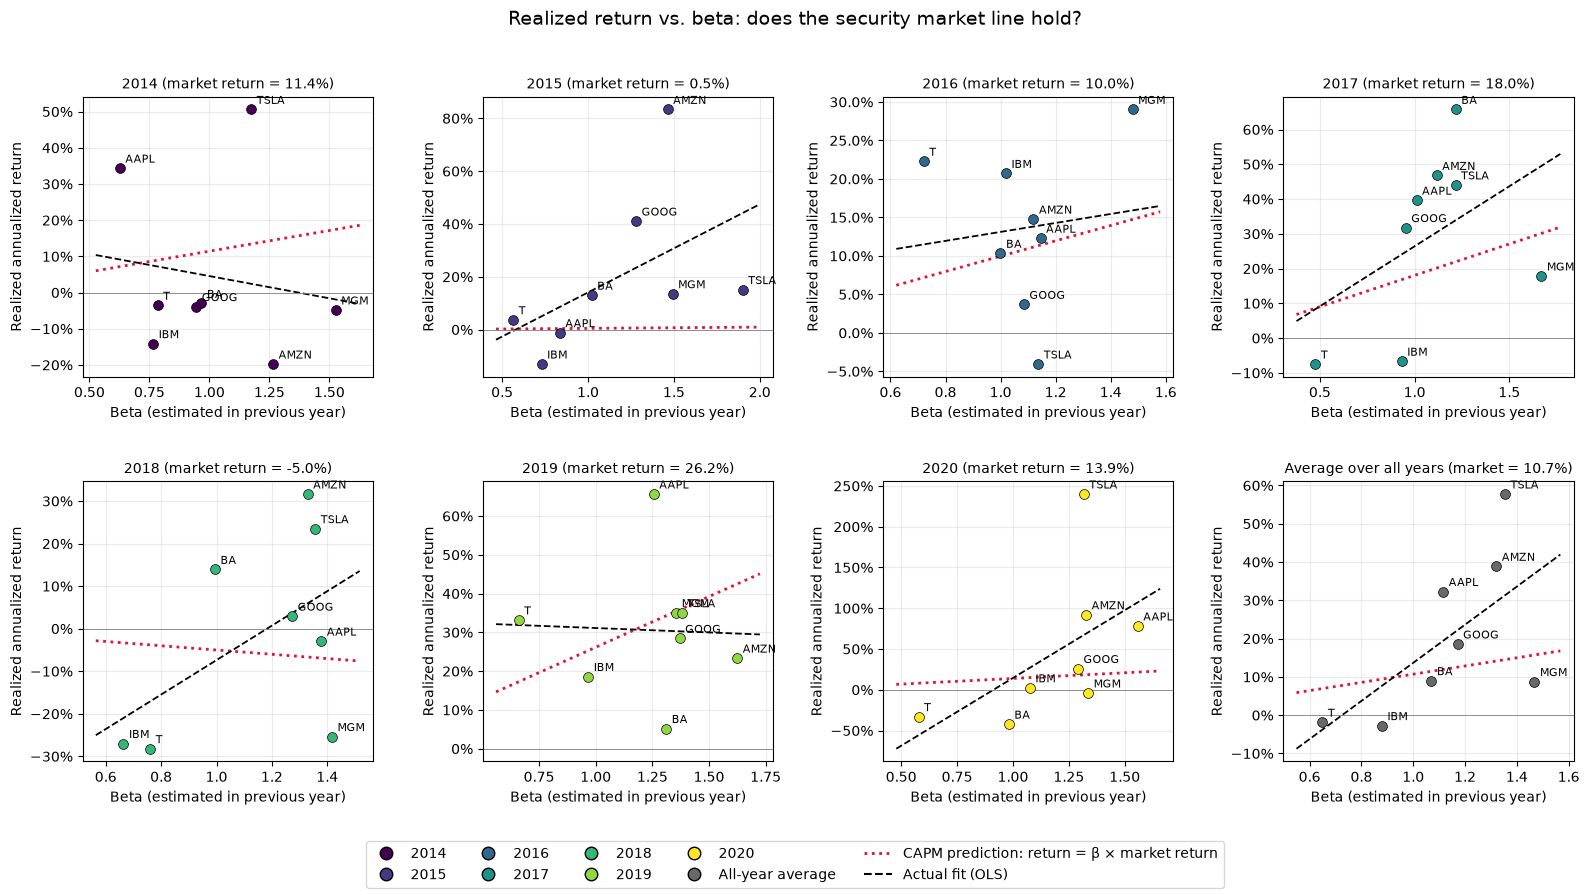

In [23]:
years = sorted(capm_evaluation["evaluation_year"].unique())
colors = dict(zip(years, plt.cm.viridis(np.linspace(0, 1, len(years)))))
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

def sml_panel(ax, beta, ret, labels, mkt, title, color="tab:blue"):
    ax.scatter(beta, ret, s=50, color=color, edgecolor="black", linewidth=0.5, zorder=3)
    for b, r, lab in zip(beta, ret, labels):
        ax.annotate(lab, (b, r), xytext=(4, 4), textcoords="offset points", fontsize=8)
    b_grid = np.linspace(beta.min() - 0.1, beta.max() + 0.1, 50)
    slope, intercept = np.polyfit(beta, ret, 1)
    ax.plot(b_grid, b_grid * mkt, color="crimson", linestyle=":", linewidth=2)               # CAPM prediction
    ax.plot(b_grid, intercept + slope * b_grid, color="black", linestyle="--", linewidth=1.3)  # empirical fit
    ax.axhline(0, color="gray", linewidth=0.6)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Beta (estimated in previous year)")
    ax.set_ylabel("Realized annualized return")
    ax.grid(alpha=0.25)

for ax, year in zip(axes.flat, years):
    d = capm_evaluation[capm_evaluation["evaluation_year"] == year]
    mkt = d["market_return"].iloc[0]
    sml_panel(ax, d["beta"].values, d["actual_return"].values, d["stock"].values, mkt,
              f"{year} (market return = {mkt:.1%})", color=colors[year])

# Last panel: each stock averaged over all years
avg = capm_evaluation.groupby("stock")[["beta", "actual_return"]].mean()
mkt_avg = capm_evaluation.groupby("evaluation_year")["market_return"].first().mean()
sml_panel(axes.flat[len(years)], avg["beta"].values, avg["actual_return"].values, avg.index,
          mkt_avg, f"Average over all years (market = {mkt_avg:.1%})", color="dimgray")

year_items = [Line2D([0], [0], marker="o", color="w", markerfacecolor=colors[y], markeredgecolor="black",
                     markersize=9, label=str(y)) for y in years]
fig.legend(handles=year_items + [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="dimgray", markeredgecolor="black", markersize=9, label="All-year average"),
    Line2D([0], [0], color="crimson", linestyle=":", linewidth=2, label="CAPM prediction: return = β × market return"),
    Line2D([0], [0], color="black", linestyle="--", label="Actual fit (OLS)"),
], loc="lower center", ncol=5)
fig.suptitle("Realized return vs. beta: does the security market line hold?", fontsize=14)
plt.tight_layout(rect=[0, 0.08, 1, 0.96], h_pad=3, w_pad=2)
save_fig("08_sml_by_year")
plt.show()

The security market line holds poorly year by year. In 2014 and 2019 the fitted line is flat or slightly downward sloping, while in 2015, 2017, 2018 and 2020 it is much steeper than the CAPM line; only 2016 comes close to the prediction. 2018 is the most telling year: the market fell, so the CAPM predicts that high-beta stocks should have lost more than low-beta ones. Instead the fitted slope is strongly positive, because AMZN and TSLA (both high beta) rose while T and IBM (both low beta) fell. In 2020 the line is extremely steep, driven by TSLA, AMZN and AAPL.

Averaged over all years (last panel), realized returns do increase with beta, but the fitted line is much steeper than the CAPM line and has a negative intercept: low-beta T and IBM earned less than predicted, and high-beta TSLA and AMZN earned far more. This is the opposite of the classic empirical finding that the security market line is *flatter* than the CAPM predicts. With only eight stocks, however, the average line reflects a few firm-specific success stories more than beta itself, as MGM shows: it has the highest average beta (1.47) but earned only about 9% a year.

### 5.4 Estimated slope vs. market return, by year

This chart condenses the panel comparison from Section 5.3. The CAPM says the slope of realized return on beta should equal that year's market return.

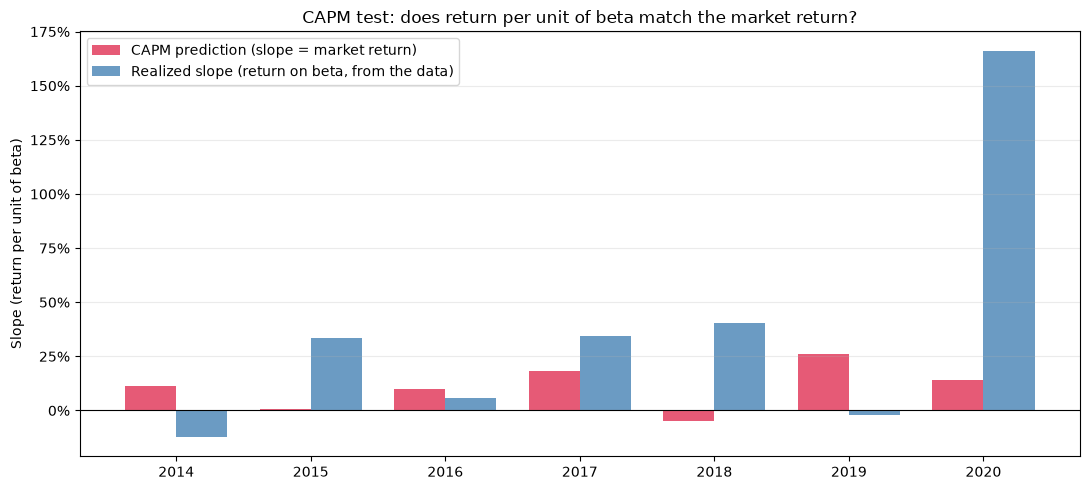

In [24]:
sml = (capm_evaluation.groupby("evaluation_year")
       .apply(lambda d: pd.Series({"slope": np.polyfit(d["beta"], d["actual_return"], 1)[0],
                                   "market_return": d["market_return"].iloc[0]}), include_groups=False)
       .reset_index())

x = np.arange(len(sml)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, sml["market_return"], w, color="crimson", alpha=0.7, label="CAPM prediction (slope = market return)")
ax.bar(x + w/2, sml["slope"], w, color="steelblue", alpha=0.8, label="Realized slope (return on beta, from the data)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(sml["evaluation_year"])
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylabel("Slope (return per unit of beta)")
ax.set_title("CAPM test: does return per unit of beta match the market return?")
ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save_fig("09_sml_slope_vs_market")
plt.show()

The blue and red bars should match under the CAPM, and they rarely do. The slope has the wrong sign in 2014 and 2019 (−12% and −2%), and in 2018 it is positive (+41%) even though the market fell. On average the slope is 38% against an average market return of 10.7%: positive, as the CAPM predicts, but not significantly different from zero (t ≈ 1.7 using the seven yearly slopes). One year dominates: excluding 2020, the average slope falls to about 17%, much closer to the 10.2% average market return of the remaining years. Large year-to-year swings are what we would expect if realized returns contain a lot of noise relative to the beta effect, which is why seven observations are not enough to confirm or reject the model.

### 5.5 How stable is beta? Yearly estimates with 95% confidence bands

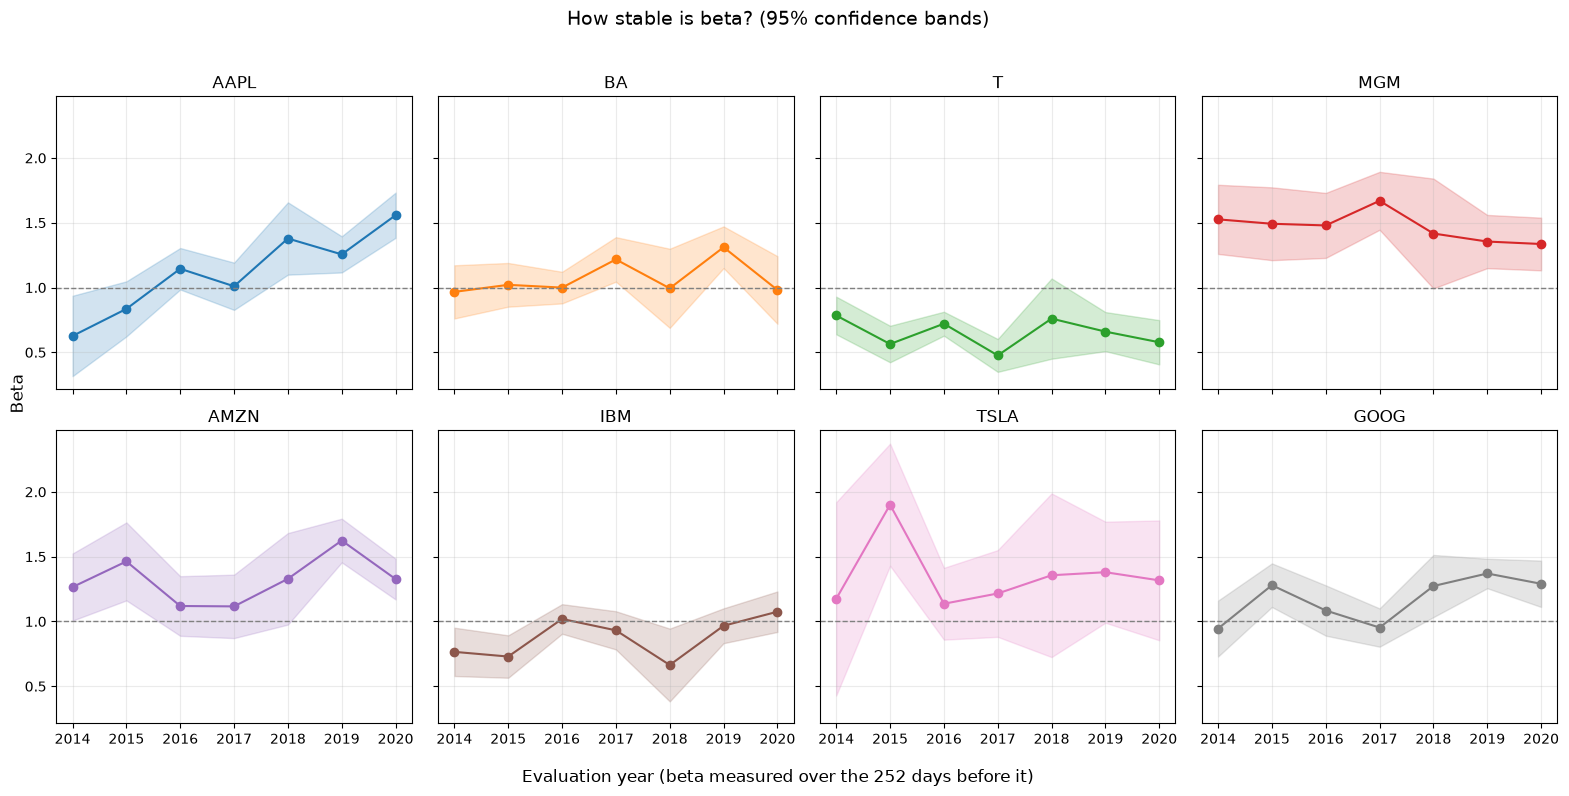

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharex=True, sharey=True)
for i, (stock, ax) in enumerate(zip(STOCKS, axes.flat)):
    d = capm_by_period[capm_by_period["stock"] == stock]
    ax.plot(d["evaluation_year"], d["beta"], marker="o", color=f"C{i}")
    ax.fill_between(d["evaluation_year"], d["beta"] - 1.96 * d["se_beta"], d["beta"] + 1.96 * d["se_beta"],
                    color=f"C{i}", alpha=0.2)
    ax.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax.set_title(stock); ax.grid(alpha=0.25)
fig.supxlabel("Evaluation year (beta measured over the 252 days before it)")
fig.supylabel("Beta")
fig.suptitle("How stable is beta? (95% confidence bands)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_fig("10_yearly_beta_stability")
plt.show()

Each point is the beta used to predict the following year's return, with its 95% confidence band. Two features stand out.

First, betas are estimated with considerable error: one year of daily data gives bands that are typically ±0.15 to ±0.3 wide, and much wider for TSLA (roughly 0.4 to 1.9 for the 2014 estimate). Second, betas drift: AAPL's beta rises steadily from about 0.6 to 1.6 between the 2014 and 2020 estimates, turning it from a defensive into an aggressive stock. The ranking is more persistent than the levels (T has the lowest beta in six of the seven years, and MGM's beta stays above 1.3 throughout), but several stocks move by more than their confidence bands from one year to the next.

Both features weaken the test. Estimation error in beta biases the estimated slope of return on beta toward zero (the errors-in-variables problem), and time variation means that last year's beta may not be the relevant risk measure this year. This is the motivation for conditional versions of the CAPM, and it is consistent with the rolling betas in Section 4.5.

### 5.6 Heatmap of prediction errors (actual − CAPM-predicted return)

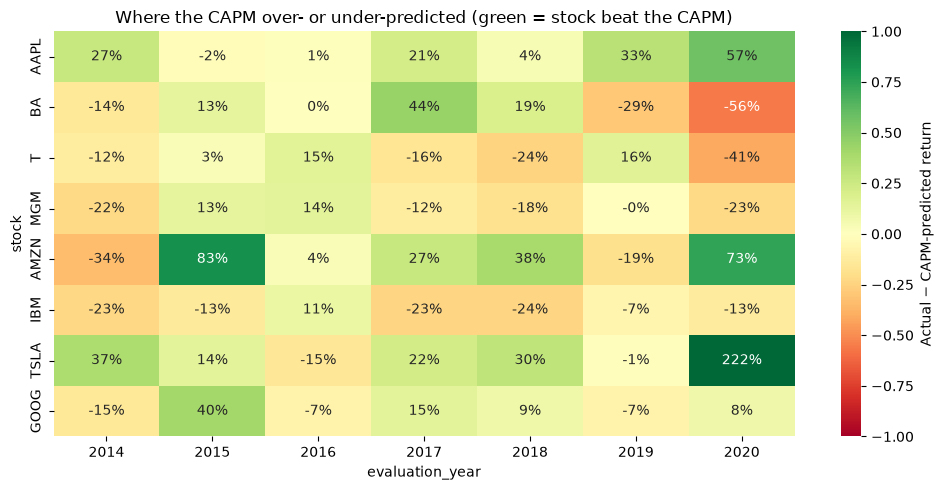

In [26]:
err = capm_evaluation.pivot(index="stock", columns="evaluation_year", values="prediction_error").loc[STOCKS]
plt.figure(figsize=(10, 5))
sns.heatmap(err, annot=True, fmt=".0%", cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            cbar_kws={"label": "Actual − CAPM-predicted return"})
plt.title("Where the CAPM over- or under-predicted (green = stock beat the CAPM)")
plt.tight_layout()
save_fig("11_prediction_error_heatmap")
plt.show()

The heatmap shows that errors are persistent by stock rather than random. TSLA, AMZN and AAPL beat the CAPM in five or six of the seven years (average errors of about +44, +24 and +20 pp), while IBM falls short in six of the seven years (−13 pp on average); T and MGM also have negative average errors (about −9 and −7 pp), with more mixed years. Broadly, growth and technology firms outperformed mature and cyclical firms over 2014–2020, a pattern that a single market factor cannot capture. It is consistent with the well-documented underperformance of value relative to growth stocks in the second half of the 2010s, which is exactly the kind of dimension that multifactor models such as Fama–French add to the CAPM.

The 2020 column shows the COVID shock: BA (−56 pp) and T (−41 pp) fell far below the prediction, and TSLA (+222 pp) and AMZN (+73 pp) far above it. This is an industry-level shock (travel and leisure vs. online retail and technology) that beta alone does not describe.

### 5.7 High-beta vs. low-beta groups each year

A simple version of the portfolio approach: each year, we split the eight stocks into the four highest and four lowest prior-year betas and compare the groups' average realized returns with the market.

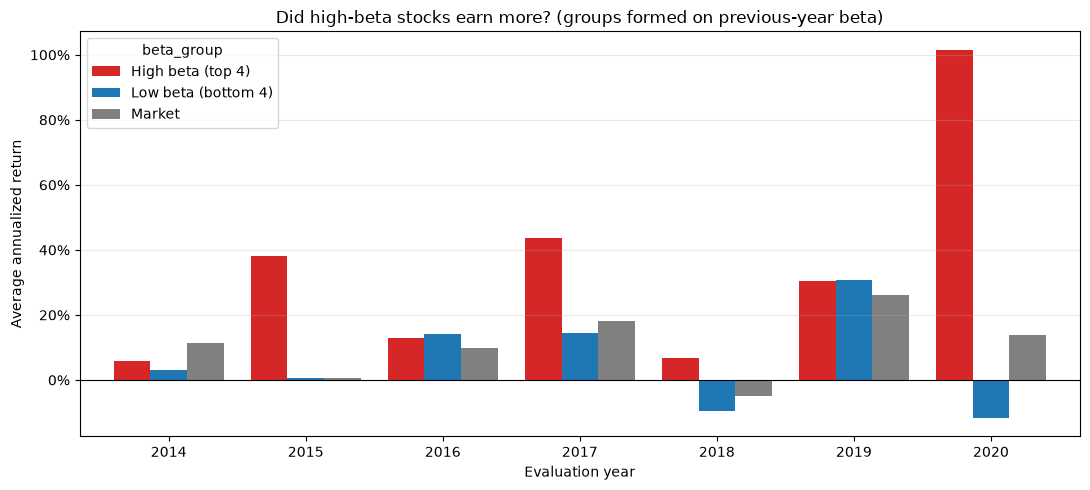

In [27]:
capm_evaluation["beta_group"] = (capm_evaluation.groupby("evaluation_year")["beta"]
    .transform(lambda b: np.where(b >= b.median(), "High beta (top 4)", "Low beta (bottom 4)")))

grp = capm_evaluation.groupby(["evaluation_year", "beta_group"])["actual_return"].mean().unstack()
grp["Market"] = capm_evaluation.groupby("evaluation_year")["market_return"].first()

ax = grp.plot(kind="bar", figsize=(11, 5), color=["tab:red", "tab:blue", "gray"], width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Evaluation year"); ax.set_ylabel("Average annualized return")
ax.set_title("Did high-beta stocks earn more? (groups formed on previous-year beta)")
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=0)
plt.tight_layout()
save_fig("12_high_vs_low_beta_groups")
plt.show()

High-beta stocks earned more on average: 34.2% a year against 6.0% for the low-beta group (market: 10.7%), and the high-beta group beat the low-beta group in 5 of the 7 years. The CAPM does predict a gap, but a much smaller one: the two groups' betas differ by about 0.45 on average, which with a 10.7% market return implies a spread of only about 4–5 pp a year, not 28 pp.

The timing also goes against the CAPM mechanism. High beta should hurt in down markets, yet in 2018 (market −5%) the high-beta group gained about 7% while the low-beta group lost about 10%. Composition explains much of this: TSLA and AMZN are in the high-beta group every year, and T and IBM are in the low-beta group every year, so the comparison largely restates the firm-specific stories seen in the heatmap, and it is heavily influenced by 2020. Four stocks per group are far too few to diversify away idiosyncratic risk, which is why Section 6 repeats this exercise with about 470 stocks.

### 5.8 Beta over different estimation windows

We repeat the analysis with betas estimated over the 63, 126, 252 and 504 trading days before each evaluation year (roughly 3 months, 6 months, 1 year and 2 years). To compare like with like, all windows are evaluated on the same years (2015–2020), since the 504-day window needs two years of history. For this reason the 252-day results differ slightly from those above.

In [28]:
windows = BETA_WINDOWS                             # 3 months, ~6 months, 1 year (baseline), 2 years
rows = []
for w in windows:
    per = split_yearly_periods(course_returns, window=w)
    for year, p in per.items():
        for stock in STOCKS:
            d = p["beta_period"][[stock, "sp500"]].dropna()
            if len(d) < w:
                continue
            res, _ = capm_regression(d[stock], d["sp500"])
            rows.append({"window": w, "stock": stock, "evaluation_year": year, "beta": res["beta"]})

beta_windows = (pd.DataFrame(rows)
    .merge(annualized_long, on=["evaluation_year", "stock"])
    .merge(market_by_year, on="evaluation_year"))
beta_windows["predicted_return"] = beta_windows["beta"] * beta_windows["market_return"]
beta_windows["prediction_error"] = beta_windows["actual_return"] - beta_windows["predicted_return"]

# same evaluation years for every window, so the comparison is fair
common_years = set(beta_windows.loc[beta_windows["window"] == max(windows), "evaluation_year"])
beta_windows = beta_windows[beta_windows["evaluation_year"].isin(common_years)]

summary = beta_windows.groupby("window").apply(lambda d: pd.Series({
    "MAE": d["prediction_error"].abs().mean(),
    "avg error": d["prediction_error"].mean(),
    "corr(beta, return)": d["beta"].corr(d["actual_return"]),
}), include_groups=False)
display(summary.style.format({"MAE": "{:.1%}", "avg error": "{:+.1%}", "corr(beta, return)": "{:.2f}"}))

,MAE,avg error,"corr(beta, return)"
window,,,
63,25.1%,+11.1%,-0.04
126,25.2%,+10.6%,0.28
252,25.0%,+10.4%,0.35
504,25.0%,+10.2%,0.33


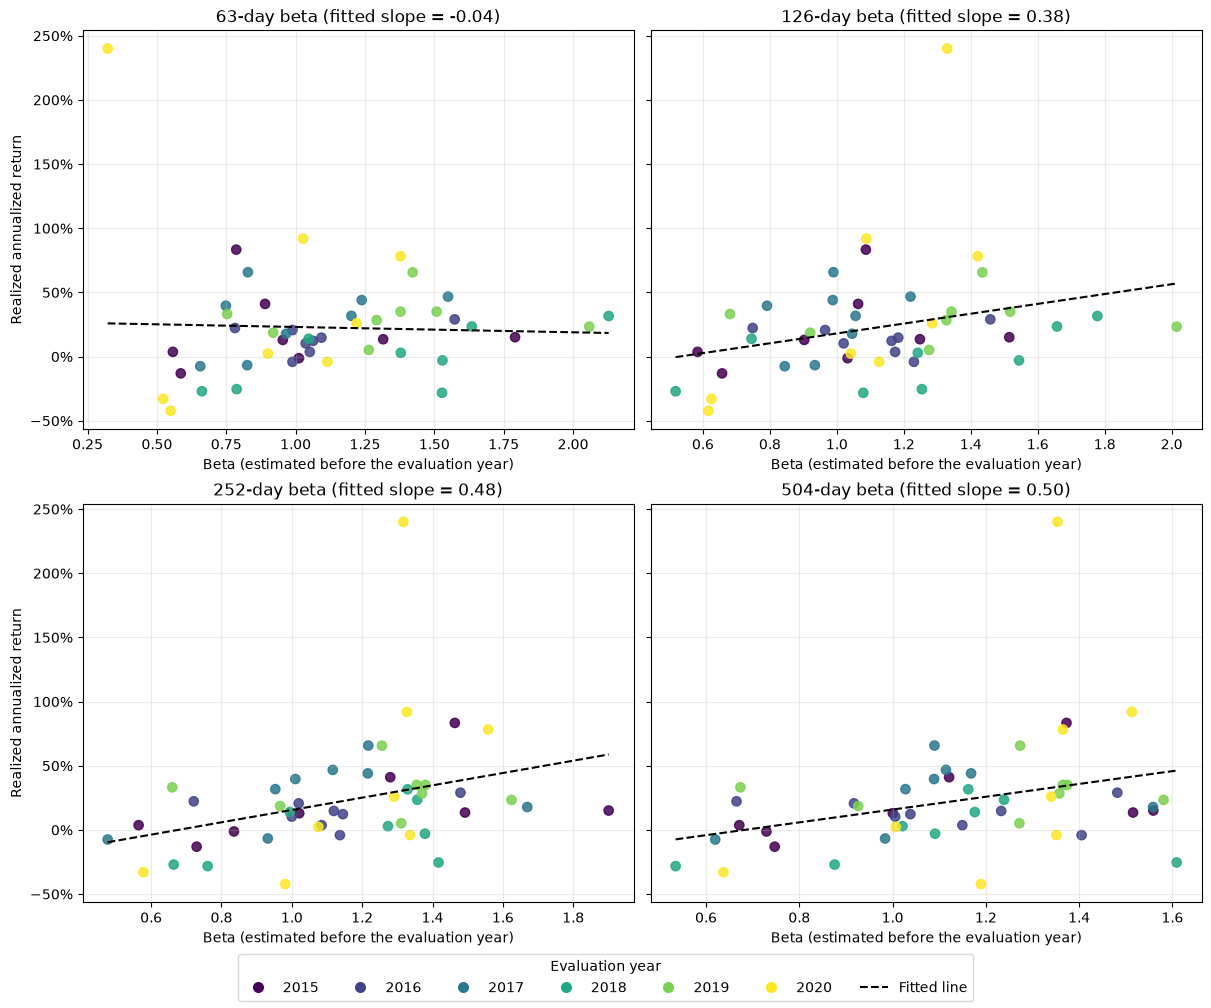

In [29]:
years = sorted(beta_windows["evaluation_year"].unique())
colors = dict(zip(years, plt.cm.viridis(np.linspace(0, 1, len(years)))))

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharey=True, layout="constrained")
for ax, w in zip(axes.flat, windows):
    d = beta_windows[beta_windows["window"] == w]
    ax.scatter(d["beta"], d["actual_return"], color=[colors[y] for y in d["evaluation_year"]], s=45, alpha=0.85)
    slope, intercept = np.polyfit(d["beta"], d["actual_return"], 1)
    b = np.linspace(d["beta"].min(), d["beta"].max(), 50)
    ax.plot(b, intercept + slope * b, color="black", linestyle="--")
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_title(f"{w}-day beta (fitted slope = {slope:.2f})")
    ax.set_xlabel("Beta (estimated before the evaluation year)")
    ax.grid(alpha=0.25)
for ax in axes[:, 0]:
    ax.set_ylabel("Realized annualized return")

legend_items = [Line2D([0], [0], marker="o", color="w", markerfacecolor=colors[y], markersize=9, label=str(y)) for y in years]
legend_items.append(Line2D([0], [0], color="black", linestyle="--", label="Fitted line"))
fig.legend(handles=legend_items, title="Evaluation year", loc="outside lower center", ncol=len(legend_items))
save_fig("13_beta_estimation_windows")
plt.show()

The window length matters for how well beta lines up with realized returns, but hardly at all for the size of the prediction errors.

With a 63-day window the relationship disappears (correlation −0.04, fitted slope −0.04): three months of daily data give betas dominated by noise and by short-lived events. The clearest example is TSLA in 2020, the point at the top left of the 63-day panel, whose three-month beta is only about 0.3 because its late-2019 rally had little to do with the market. With 126, 252 and 504 days the correlation rises to 0.28-0.35 and the fitted slope stabilizes at about 0.4–0.5, with little difference between one and two years. This is the classic trade-off: longer windows reduce estimation error (which biases the slope toward zero), but if beta drifts over time, as seen in Section 5.5, very long windows rely on stale information. In our sample, one to two years is a reasonable compromise.

By contrast, the mean absolute error is about 25 pp and the average error about +10 pp for every window. A better beta cannot fix this: an error of 0.3 in beta, multiplied by a typical market return of 10%, changes the prediction by only 3 pp, while the firm-specific part of a single stock's annual return is often several times larger. The quality of the prediction is limited by idiosyncratic risk, not by how beta is measured.

### 5.9 Economic interpretation

**What the CAPM predicts.** With $r_f = 0$, the Sharpe–Lintner CAPM says that expected returns are linear in beta, $E[r_i] = \beta_i \, E[r_M]$. The security market line should have a zero intercept and a slope equal to the market return; beta should be the only priced characteristic; and firm-specific risk should earn no premium, because investors can diversify it away. Our year-by-year test checks these predictions ex post: in each year, the slope of realized returns on beta should equal the realized market return.

**Predictions are poor for individual stocks.** Using the previous year's beta and the current year's market return, the CAPM misses realized annual returns by 24.7 pp on average. This is consistent with Section 4, where the market explained only 15–50% of daily variance: most of what happens to a single stock over a year is idiosyncratic. The CAPM is a model of expected returns for diversified investors, not a forecast of one stock's return in one year.

**Beta and return are positively related, but not in the way the CAPM predicts.** Realized returns rise with beta on average (average slope 38%; the high-beta group earned 34% a year against 6% for the low-beta group), but the slope is far too variable to be informative: it is negative in 2014 and 2019, positive in 2018 when the market fell, and not significantly different from zero (t ≈ 1.7). Where it is large, it is much steeper than the market return, mostly because of 2020 and a few firms. This is the opposite of the best-known empirical result, that the security market line is too *flat*: low-beta stocks earn more and high-beta stocks less than the CAPM predicts (Black, Jensen and Scholes, 1972; Fama and French, 2004; Frazzini and Pedersen's "betting against beta", 2014). We attribute the difference to our sample rather than to a genuine steepening: eight non-randomly chosen stocks, seven years, and a period in which the market rose strongly and growth and technology stocks, which also happened to have high betas, did exceptionally well.

**Errors are systematic by firm, which points to missing factors.** TSLA, AMZN and AAPL beat the CAPM in most years, while IBM falls short in almost every year. Persistent same-sign errors mean that something other than market beta is priced (or mispriced) in this sample. Candidates discussed in the literature include size, value (book-to-market) and momentum, as well as industry-level shocks such as COVID-19, which hit travel and leisure (BA, MGM) and helped online retail and technology (AMZN, TSLA). Part of IBM's and T's shortfall may also be mechanical, since the course prices exclude dividends and these are the two highest-yield stocks.

**Beta itself is hard to measure.** Yearly betas have wide confidence bands and drift over time (AAPL from about 0.6 to 1.6). Estimation error biases the estimated slope toward zero, and very short windows (63 days) destroy the relationship entirely. Windows of one to two years work best, but no window reduces the prediction errors, which are driven by idiosyncratic risk.

**Conclusion.** Our results neither confirm nor clearly reject the CAPM. Beta is a meaningful measure of co-movement with the market, and on average riskier stocks earned more, which is the CAPM's core intuition. But beta alone is a poor guide to what an individual stock will earn in a given year, the beta–return relation is unstable from year to year, and the systematic firm-level errors suggest that other risk factors matter. A cleaner test requires many stocks grouped into portfolios and formal test statistics, which we attempt in Section 6. The limitations of the test are summarized in Section 7.

## 6. Extension: cross-sectional tests on the S&P 500 (CRSP, 2007–2023)

This section reproduces the main empirical exercises of Fama and French (2004), *The Capital Asset Pricing Model: Theory and Evidence* (Journal of Economic Perspectives), on the CRSP S&P 500 panel (2007–2023) described in Section 6.1. It addresses the weaknesses of the test in Section 5 (only eight stocks, noisy individual betas, no formal test) in four steps:

1. beta-sorted decile portfolios and an analogue of the paper's Figure 2;
2. a discussion of the book-to-market evidence (Figure 3), which we cannot replicate without Compustat data;
3. Fama–MacBeth cross-sectional regressions;
4. the Gibbons–Ross–Shanken (GRS) test of whether all portfolio alphas are jointly zero.

Apart from the imports and configuration in Section 1, the section is self-contained and can be run independently of Sections 2–5.

### 6.1 Data: the CRSP panel

**Why CRSP rather than Wikipedia and Yahoo Finance.** A simple way to build an S&P 500 sample would be to scrape the list of S&P 500 tickers from Wikipedia and downloading prices with yfinance. We chose instead to download the daily CRSP panel of S&P 500 constituents from WRDS (Wharton Research Data Services), because the scraping approach suffers from a double survivorship bias. First, Wikipedia only lists the current members of the index, so firms that were in the S&P 500 during our sample but later left it (after a bankruptcy, an acquisition or a removal) are missing from the ticker list. Second, Yahoo Finance generally does not keep the price history of delisted firms, so even with the historical tickers the data for these firms would contain large gaps. A sample built this way would contain mostly surviving firms, which tend to be the winners, and would overstate average returns.

CRSP does not have this problem: it covers every firm that belonged to the index during 2007–2023, including those that were later delisted, with a permanent identifier (PERMNO) that does not change when tickers do. It also provides total returns (including dividends) and market capitalizations, which we need to build value-weighted portfolios. For these reasons we use CRSP as our source for this section.

The extract contains the daily records of all stocks that were S&P 500 constituents on each date, 2007–2023. The function below loads it, keeps the needed fields and applies the cleaning: zero prices (delisting days without a market price) are set to missing, and rows with no return are dropped. Only summaries are shown, since CRSP data are licensed and cannot be redistributed.

In [30]:
CRSP_COLUMNS = {
    "DlyCalDt": "date", "PERMNO": "permno", "Ticker": "ticker",
    "DlyPrc": "price", "DlyRet": "ret", "DlyCumFacPr": "adj_factor",
    "DlyCap": "mcap", "DlyPrcFlg": "price_flag",
}


def load_crsp_panel(path, start=None, end=None, return_raw=False):
    """Load and clean the CRSP daily file.

    Cleaning: zero price -> NaN (delisting day, no market price); rows without a
    return are dropped. With return_raw=True, also return the renamed but
    uncleaned data, used for the quality checks below."""
    raw = pd.read_csv(path, usecols=list(CRSP_COLUMNS), parse_dates=["DlyCalDt"])
    if start:
        raw = raw[raw["DlyCalDt"] >= start]
    if end:
        raw = raw[raw["DlyCalDt"] <= end]
    raw = raw.rename(columns=CRSP_COLUMNS)

    panel = raw.copy()
    panel.loc[panel["price"] == 0, "price"] = np.nan   # zero price = delisting day, no market price
    panel = panel.dropna(subset=["ret"]).sort_values(["permno", "date"]).reset_index(drop=True)
    return (panel, raw) if return_raw else panel


panel, crsp_raw = load_crsp_panel(CRSP_FILE, CRSP_START, CRSP_END, return_raw=True)

# Overview of the raw extract (structure only: CRSP rows are licensed and not displayed)
print("Shape:", crsp_raw.shape)
print("Period:", crsp_raw["date"].min().date(), "to", crsp_raw["date"].max().date())
print("Distinct stocks (PERMNO):", crsp_raw["permno"].nunique())
crsp_raw.dtypes.rename("dtype").to_frame()

Shape: (2149139, 8)
Period: 2007-01-03 to 2023-12-29
Distinct stocks (PERMNO): 891


,dtype
permno,int64
ticker,str
date,datetime64[us]
price,float64
price_flag,str
mcap,float64
ret,float64
adj_factor,float64


The CRSP dataset contains around 2.15 million daily observations (2007-01-03 to 2023-12-29) in long format (one row per stock-day), i.e. about 500 stocks per trading day, consistent with S&P 500 membership.

It includes firms that later left the index or were delisted, which avoids survivorship bias. Returns (ret) come directly from CRSP, are expressed in decimals, include dividends and are already adjusted for splits; market capitalization is expressed in thousands of dollars.

**Why more variables than in `Data_Stock.csv`?** The course file is a small wide table with one closing-price column per stock plus the index, which is all that is needed to compute returns for eight fixed firms. CRSP is a research database designed for a changing universe of firms, so it stores additional information: a permanent identifier (PERMNO), because tickers change over time; returns that already include dividends; cumulative adjustment factors for splits; market capitalization, needed for value weighting; and price flags that identify delistings and prices that are not actual trades. These fields are what allow us to build a survivorship-free, value-weighted market portfolio and beta-sorted portfolios in the rest of this section.

**Quality checks on the raw extract**

In [31]:
# Missing values and zeros
print("Missing values:\n", crsp_raw.isna().sum())
print("\nZeros:\n", (crsp_raw[["price", "ret", "mcap"]] == 0).sum())
print("\nNegative prices:", (crsp_raw["price"] < 0).sum())

Missing values:
 permno         0
ticker        67
date           0
price          4
price_flag     0
mcap          70
ret           77
adj_factor    66
dtype: int64

Zeros:
 price       62
ret      15425
mcap         0
dtype: int64

Negative prices: 0


In [32]:
# Consistency checks
print("Duplicates (same stock, same day):", crsp_raw.duplicated(subset=["permno", "date"]).sum())

stocks_per_day = crsp_raw.groupby("date")["permno"].nunique()
print("Stocks per day: min", stocks_per_day.min(), "| mean", round(stocks_per_day.mean()), "| max", stocks_per_day.max())

Duplicates (same stock, same day): 0
Stocks per day: min 498 | mean 502 | max 508


In [33]:
# Price flag: TR = closing trade, BA = bid/ask average, DA/DP = delisting day
crsp_raw["price_flag"].value_counts()

price_flag
TR    2149066
DA         62
DP          4
MP          3
BA          3
NT          1
Name: count, dtype: int64

In [34]:
# Zero prices vs price flag
pd.crosstab(crsp_raw["price_flag"], crsp_raw["price"] == 0)

price,False,True
price_flag,,
BA,3,0
DA,0,62
DP,4,0
MP,3,0
NT,1,0
TR,2149066,0


In [35]:
# Do delisting days (DA) have a return?
print("Missing returns on DA days:", crsp_raw.loc[crsp_raw["price_flag"] == "DA", "ret"].isna().sum())

Missing returns on DA days: 0


**Cleaning**

In [36]:
print("Rows dropped:", len(crsp_raw) - len(panel))

Rows dropped: 77


The 77 dropped rows are mainly spin-offs on their first trading day: with no price at t−1, no return can be computed.

In [37]:
# Check after cleaning
print("Shape:", panel.shape, "| Stocks:", panel["permno"].nunique())
print("Missing values:\n", panel.isna().sum())
pd.crosstab(panel["price_flag"], panel["ticker"].isna())

Shape: (2149062, 8) | Stocks: 873
Missing values:
 permno         0
ticker        64
date           0
price         62
price_flag     0
mcap          64
ret            0
adj_factor    64
dtype: int64


ticker,False,True
price_flag,,
BA,3,0
DA,0,62
DP,0,2
TR,2148995,0


After cleaning, the dataset has no missing returns and covers 873 distinct stocks; the remaining missing prices, tickers and market caps all fall on delisting days (DA/DP), which are kept because their returns capture the final payoff to shareholders and avoid survivorship bias.

In [38]:
del crsp_raw   # only the cleaned panel is used from here on

### 6.2 Market return series built from the panel

The CRSP extract doesn't include a separate index column, so we build a value-weighted market return the same way CRSP's own index is built: each stock's weight on day *t* is its market cap at *t-1* (not *t*, so today's return isn't mechanically tied to today's weight), renormalized across whichever stocks are trading that day.

In [39]:
def value_weighted_market_return(panel):
    """CRSP-style value-weighted daily market return, built from the panel."""
    p = panel[["date", "permno", "ret", "mcap"]].copy()
    p["lag_mcap"] = p.groupby("permno")["mcap"].shift(1)   # yesterday's cap avoids look-ahead weighting
    p = p.dropna(subset=["lag_mcap", "ret"])

    def _wavg(g):
        w = g["lag_mcap"] / g["lag_mcap"].sum()
        return (w * g["ret"]).sum()

    mkt = p.groupby("date").apply(_wavg, include_groups=False)
    mkt.name = "mkt_ret"
    return mkt

mkt_ret = value_weighted_market_return(panel)
print(f"Market return series: {len(mkt_ret)} days, mean daily = {mkt_ret.mean():.5f}, "
      f"annualized = {mkt_ret.mean()* TRADING_DAYS:.2%}")

Market return series: 4277 days, mean daily = 0.00045, annualized = 11.24%


The value-weighted market built from the panel earns 11.2% a year on average over 2007–2023. Unlike the S&P 500 price index used in Sections 3–5, it is built from CRSP returns, which include dividends, so it is closer to a total-return market proxy. It is still only a proxy: it covers about 500 large US stocks and excludes small caps, bonds, real estate and human capital, which is the essence of Roll's critique.

### 6.3 Preranking betas and beta-sorted decile portfolios (Figure 2)

For each formation date, we estimate every stock's **preranking beta** from its trailing daily returns, sort stocks into 10 value-weighted deciles, and hold that portfolio for the following year. This is the same annual rebalancing idea as in Section 5, applied to portfolios of many stocks instead of to each of the eight stocks individually.

`PRERANK_WINDOW` is set to about two years of daily data, shorter than the paper's two to five years of *monthly* data, so that enough of the 2007–2023 sample is left for the holding periods. Our results in Section 5.8 suggest that one to two years is a reasonable window.

In [40]:
def preranking_betas(panel, mkt_ret, formation_date, window_days=PRERANK_WINDOW, min_obs=MIN_OBS):
    """OLS beta per stock, estimated on daily returns over the window_days
    trading days immediately before formation_date."""
    lo = formation_date - pd.Timedelta(days=int(window_days * 1.6))  # buffer for weekends/holidays
    hist = panel[(panel["date"] < formation_date) & (panel["date"] >= lo)]
    hist = hist.sort_values("date").groupby("permno").tail(window_days)

    mkt = mkt_ret[(mkt_ret.index < formation_date) & (mkt_ret.index >= lo)].tail(window_days)

    betas = {}
    for permno, g in hist.groupby("permno"):
        s = g.set_index("date")["ret"]
        aligned = pd.concat([s.rename("stock"), mkt.rename("mkt")], axis=1, join="inner").dropna()
        if len(aligned) < min_obs:
            continue
        x = sm.add_constant(aligned["mkt"])
        model = sm.OLS(aligned["stock"], x).fit()
        betas[permno] = model.params["mkt"]

    return pd.Series(betas, name="preranking_beta")

In [41]:
def latest_mcap_before(panel, permnos, asof_date, lookback_days=15):
    """Most recent market cap on or before asof_date, per stock — used as
    the value-weighting base at portfolio formation."""
    window = panel[(panel["permno"].isin(permnos)) &
                    (panel["date"] <= asof_date) &
                    (panel["date"] > asof_date - pd.Timedelta(days=lookback_days))]
    return window.sort_values("date").groupby("permno")["mcap"].last()

def assign_deciles(score, n_deciles=N_DECILES):
    """Decile 1 = lowest score (beta or B/M), decile n = highest."""
    ranks = score.rank(method="first")   # 'first' breaks exact ties deterministically
    deciles = pd.qcut(ranks, n_deciles, labels=range(1, n_deciles + 1))
    return deciles.astype(int)

def portfolio_returns_for_period(panel, membership, formation_date, next_formation_date):
    """Value-weight each decile's daily return over the holding period.
    Weights are fixed at the formation-date market cap (a standard
    simplification, the more precise version lets weights drift with
    prices during the holding period, which we skip here for clarity)."""
    hold = panel[(panel["date"] >= formation_date) & (panel["date"] < next_formation_date)]
    hold = hold.merge(membership[["decile", "weight"]], left_on="permno", right_index=True, how="inner")

    def _vw(g):
        w = g["weight"] / g["weight"].sum()
        return (w * g["ret"]).sum()

    port_ret = hold.groupby(["date", "decile"]).apply(_vw, include_groups=False)
    return port_ret.rename("ret").reset_index()

In [42]:
def decile_portfolio_returns_for_year(panel, mkt_ret, formation_date, next_formation_date,
                                       window_days=PRERANK_WINDOW, n_deciles=N_DECILES, min_obs=MIN_OBS):
    """One formation cycle: preranking betas -> deciles -> value-weight -> hold one year."""
    betas = preranking_betas(panel, mkt_ret, formation_date, window_days, min_obs)
    if betas.empty or len(betas) < n_deciles:
        return None, None

    weights = latest_mcap_before(panel, betas.index, formation_date)
    common = betas.index.intersection(weights.index)
    betas = betas.loc[common]
    deciles = assign_deciles(betas, n_deciles)

    membership = pd.DataFrame({"beta": betas, "decile": deciles, "weight": weights.loc[common]})
    port_ret = portfolio_returns_for_period(panel, membership, formation_date, next_formation_date)
    return port_ret, membership

def build_decile_portfolios(panel, mkt_ret, start_year, end_year,
                             window_days=PRERANK_WINDOW, n_deciles=N_DECILES, min_obs=MIN_OBS):
    """Repeat the annual formation cycle across years, and stitch the
    decile return series together into one wide DataFrame (D1..D10)."""
    all_returns, all_membership = [], {}
    for year in range(start_year, end_year):
        formation_date = pd.Timestamp(f"{year}-01-01")
        next_formation = pd.Timestamp(f"{year + 1}-01-01")
        port_ret, membership = decile_portfolio_returns_for_year(
            panel, mkt_ret, formation_date, next_formation, window_days, n_deciles, min_obs)
        if port_ret is None:
            print(f"Skipping {year}: not enough history yet for a full set of deciles.")
            continue
        all_returns.append(port_ret)
        all_membership[year] = membership

    decile_returns = pd.concat(all_returns, ignore_index=True)
    decile_returns = decile_returns.pivot(index="date", columns="decile", values="ret")
    decile_returns.columns = [f"D{int(c)}" for c in decile_returns.columns]
    return decile_returns, all_membership

In [43]:
START_YEAR = panel["date"].dt.year.min() + int(np.ceil(PRERANK_WINDOW / TRADING_DAYS)) + 1
END_YEAR = panel["date"].dt.year.max() + 1

decile_returns, membership_by_year = build_decile_portfolios(panel, mkt_ret, START_YEAR, END_YEAR)
print("Decile return panel:", decile_returns.shape)
print("Stocks per formation year:", {y: len(m) for y, m in membership_by_year.items()})
decile_returns.head()

Decile return panel: (3522, 10)
Stocks per formation year: {2010: 452, 2011: 472, 2012: 473, 2013: 473, 2014: 473, 2015: 474, 2016: 471, 2017: 462, 2018: 468, 2019: 471, 2020: 474, 2021: 477, 2022: 480, 2023: 479}


,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
date,,,,,,,,,,
2010-01-04,0.006112,0.016954,0.006207,0.015682,0.014389,0.014598,0.024271,0.025422,0.025566,0.026438
2010-01-05,-0.003849,-0.007319,-0.002530,0.000943,0.004491,0.000742,0.007043,0.011788,0.010280,0.024222
2010-01-06,0.000247,-0.000086,0.000649,-0.010052,0.003877,-0.002301,0.004868,0.008926,0.007359,0.008633
2010-01-07,-0.001430,0.002564,0.000695,-0.003258,0.000916,0.002138,0.012903,0.003452,0.008499,0.024271
2010-01-08,-0.001911,0.002230,0.004583,0.005353,0.004418,0.004692,0.008917,0.007675,0.001238,-0.005187


Portfolios are formed every January from 2010 to 2023 (the first years of data are used only to estimate the first preranking betas), with 452 to 480 stocks per year, i.e. roughly 45–48 stocks per decile. Unlike the groups of four in Section 5.7, each decile is diversified enough for most of the idiosyncratic noise to cancel out.

### 6.4 Postranking betas and the Figure 2 analog

Fama and French's key methodological point is that **individual-stock betas are noisy** (as our beta-stability plot in Section 5.5 shows directly), so they re-estimate beta *after* forming the deciles, on each decile portfolio's full-sample return. Averaging across many stocks removes most of the idiosyncratic noise, which makes the postranking beta a much cleaner risk measure. This is the step our eight-stock version in Section 5 could not do.

In [44]:
def postranking_betas(decile_returns, mkt_ret):
    """Regress each decile's full-sample return on the market to get its
    postranking beta -- this is what the paper actually plots on the x-axis."""
    aligned = decile_returns.join(mkt_ret, how="inner").dropna()
    results = {}
    for col in decile_returns.columns:
        x = sm.add_constant(aligned["mkt_ret"])
        model = sm.OLS(aligned[col], x).fit()
        results[col] = {"postranking_beta": model.params["mkt_ret"],
                         "avg_daily_return": aligned[col].mean()}
    return pd.DataFrame(results).T

fig2_data = postranking_betas(decile_returns, mkt_ret)
fig2_data["avg_annual_return"] = fig2_data["avg_daily_return"] * TRADING_DAYS
fig2_data

,postranking_beta,avg_daily_return,avg_annual_return
D1,0.621152,0.000389,0.098132
D2,0.771586,0.000444,0.111890
D3,0.818329,0.000509,0.128270
D4,0.939862,0.000452,0.114018
D5,1.053428,0.000476,0.119842
D6,1.058536,0.000627,0.158032
D7,1.171911,0.000580,0.146046
D8,1.241374,0.000515,0.129663
D9,1.261395,0.000702,0.176809
D10,1.331988,0.000753,0.189829


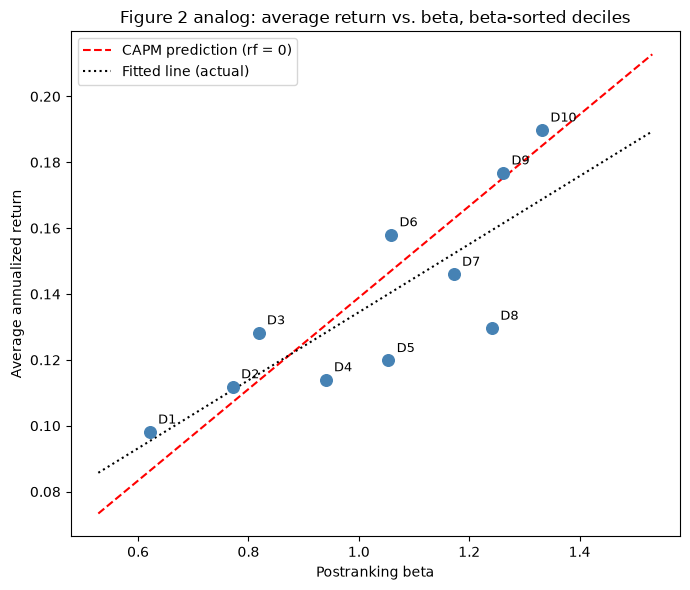

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(fig2_data["postranking_beta"], fig2_data["avg_annual_return"],
           color="steelblue", s=70, zorder=3)
for label, row in fig2_data.iterrows():
    ax.annotate(label, (row["postranking_beta"], row["avg_annual_return"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

# CAPM-predicted line (rf = 0): E[r] = beta * E[r_M], with the market mean over the same period as the deciles (2010–2023)
mkt_avg_annual = mkt_ret.loc[decile_returns.index].mean() * TRADING_DAYS
beta_grid = np.linspace(fig2_data["postranking_beta"].min() * 0.85,
                         fig2_data["postranking_beta"].max() * 1.15, 50)
ax.plot(beta_grid, beta_grid * mkt_avg_annual, color="red", linestyle="--",
        label="CAPM prediction (rf = 0)")

# actual fitted line across the deciles
slope, intercept = np.polyfit(fig2_data["postranking_beta"], fig2_data["avg_annual_return"], 1)
ax.plot(beta_grid, intercept + slope * beta_grid, color="black", linestyle=":",
        label="Fitted line (actual)")

ax.set_xlabel("Postranking beta")
ax.set_ylabel("Average annualized return")
ax.set_title("Figure 2 analog: average return vs. beta, beta-sorted deciles")
ax.legend()
plt.tight_layout()
save_fig("14_beta_decile_sml")
plt.show()

**Result.** Sorting on preranking beta produces a wide and well-ordered spread of postranking betas, from 0.62 (D1) to 1.33 (D10), which confirms that past beta predicts future beta at the portfolio level. Average returns rise with beta, from 9.8% for D1 to 19.0% for D10, and the relationship is close to linear (the fitted line has a slope of about 10.3% per unit of beta and an intercept of about 3.1%). This is much cleaner than anything we could obtain with eight stocks in Section 5.

**How to read the red line.** The CAPM line uses the average market return over the same period as the decile portfolios (2010–2023, 13.9% a year), so the vertical distance between each point and the line is that decile's alpha. These gaps are small (between about −4% and +1.5% a year) and, as the GRS test below shows, not jointly significant.

**Comparison with the paper.** Fama and French (2004) find that over 1928–2003 the relation between beta and average return is much flatter than the CAPM predicts: low-beta portfolios earn more than predicted and high-beta portfolios less. We find the same pattern in a much weaker form: our fitted line is flatter than the CAPM line, with the low-beta deciles above it and most higher-beta deciles below it. Our fitted slope (about 10.3%) is somewhat below the market's 13.9% and the intercept is positive (about 3.1% instead of 0), but the deviations are small. Likely reasons are (i) our universe contains only large S&P 500 firms, among which anomalies tend to be weaker; (ii) our 14-year sample is short and dominated by a long bull market, in which high-beta stocks mechanically did well ex post; and (iii) we set $r_f = 0$: with a positive risk-free rate the CAPM would predict an intercept equal to $r_f$ and a slope equal to the market *excess* return, which would bring the prediction closer to our fitted line.

### 6.5 Book-to-market decile portfolios (Figure 3)

One of the paper's main pieces of evidence against the CAPM comes from portfolios sorted on book-to-market equity (B/M). In Fama and French (2004), average returns rise strongly from the lowest-B/M ("growth") portfolios to the highest-B/M ("value") portfolios, while betas barely change and even move slightly in the opposite direction. The positive relation between beta and return predicted by the CAPM is therefore absent: beta fails to explain return differences associated with another observable characteristic, which directly contradicts the model.

We do not replicate this figure: book equity is a Compustat field and is not included in our CRSP extract.

### 6.6 Fama–MacBeth cross-sectional regressions

The cross-sectional test in Section 5 uses one observation per stock per **year** (8 stocks × 7 years), which is why its t-statistic is unreliable. A proper Fama–MacBeth (1973) regression instead runs one cross-sectional regression of returns on beta per **month**, across every stock in the panel, and then averages the monthly slopes. The standard error comes from how much the slope varies from month to month. Beta is re-estimated once a year, as in Section 5, to keep this comparable with the rest of the notebook.

In [46]:
def fama_macbeth(panel, mkt_ret, beta_window_days=PRERANK_WINDOW, min_stocks=FM_MIN_STOCKS, min_obs=MIN_OBS):
    panel = panel.copy()
    panel["year"] = panel["date"].dt.year
    panel["month"] = panel["date"].dt.to_period("M")

    # compound daily returns up to monthly
    monthly_ret = (panel.groupby(["permno", "month"])["ret"]
                   .apply(lambda r: (1 + r).prod() - 1)
                   .rename("monthly_ret").reset_index())

    # one beta estimate per stock per year (same cadence as Section 5)
    beta_by_year = {}
    for year in sorted(panel["year"].unique()):
        formation_date = pd.Timestamp(f"{year}-01-01")
        beta_by_year[year] = preranking_betas(panel, mkt_ret, formation_date, beta_window_days, min_obs)

    slopes = []
    for month in sorted(monthly_ret["month"].unique()):
        year = month.year
        if year not in beta_by_year or beta_by_year[year].empty:
            continue
        betas = beta_by_year[year]
        cross = monthly_ret[monthly_ret["month"] == month].set_index("permno")["monthly_ret"]
        merged = pd.concat([cross, betas], axis=1, join="inner").dropna()
        if len(merged) < min_stocks:
            continue
        x = sm.add_constant(merged["preranking_beta"])
        model = sm.OLS(merged["monthly_ret"], x).fit()
        slopes.append({"month": month, "slope": model.params["preranking_beta"],
                        "intercept": model.params["const"], "n_stocks": len(merged)})

    slopes_df = pd.DataFrame(slopes)
    mean_slope = slopes_df["slope"].mean()
    se_slope = slopes_df["slope"].std() / np.sqrt(len(slopes_df))   # Fama-MacBeth SE: std of slopes / sqrt(T)
    t_stat = mean_slope / se_slope
    summary = {"mean_slope_monthly": mean_slope, "se_slope": se_slope,
               "t_stat": t_stat, "n_months": len(slopes_df)}
    return slopes_df, summary

fm_slopes, fm_summary = fama_macbeth(panel, mkt_ret)
print(fm_summary)
fm_slopes.head()

{'mean_slope_monthly': np.float64(0.0064624991937606464), 'se_slope': np.float64(0.004807123949155042), 't_stat': np.float64(1.3443587604801772), 'n_months': 180}


,month,slope,intercept,n_stocks
0,2009-01,-0.116285,0.044133,440
1,2009-02,-0.091438,-0.023269,438
2,2009-03,0.136171,-0.029707,437
3,2009-04,0.239067,-0.071784,433
4,2009-05,0.160308,-0.110437,432


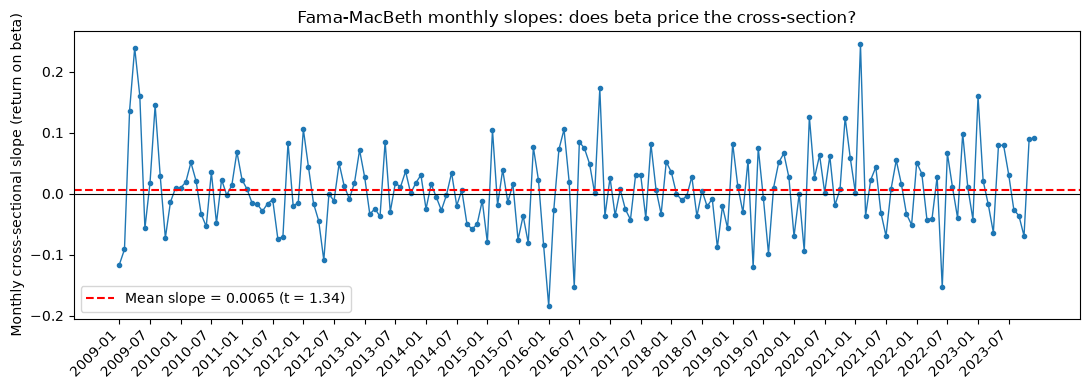

In [47]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(fm_slopes["month"].astype(str), fm_slopes["slope"], marker="o", markersize=3, linewidth=1)
ax.axhline(fm_summary["mean_slope_monthly"], color="red", linestyle="--",
           label=f"Mean slope = {fm_summary['mean_slope_monthly']:.4f} (t = {fm_summary['t_stat']:.2f})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(ax.get_xticks()[::6])
ax.set_ylabel("Monthly cross-sectional slope (return on beta)")
ax.set_title("Fama-MacBeth monthly slopes: does beta price the cross-section?")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig("15_fama_macbeth_slopes")
plt.show()

**Result.** Over 180 months (2009–2023), with several hundred stocks in each cross-section, the average slope is 0.65% per month (about 7.8% per year), with a t-statistic of 1.34. The premium for beta is positive, as the CAPM predicts, but not statistically significant. Under the CAPM (with $r_f = 0$) the average slope should equal the average market return, between about 0.9% and 1.2% per month depending on the period used. Our estimate is below that, but the difference is within about one standard error (0.48%). The test therefore cannot distinguish "beta is priced as the CAPM says" from "beta is not priced at all". This is a problem of power: the monthly slope is extremely volatile, ranging from about −18% to +25% per month.

The plot shows why. Each month's slope behaves like a bet on the market: it is strongly positive in rising months (for example the 2009 rebound and the late-2020 rally) and strongly negative in falling months, because high-beta stocks amplify whatever the market does. This is exactly what the CAPM implies ex post, and it is why a precise estimate of the beta premium requires very long samples (Fama and French use several decades of data). Finally, this regression uses individual-stock betas, which are noisy; errors-in-variables bias the slope toward zero, which is consistent with it being smaller than the slope across decile portfolios (about 10% per year).

### 6.7 The GRS test

Gibbons, Ross & Shanken (1989): a formal test of whether the market proxy is mean-variance efficient relative to the decile portfolios, i.e. whether the postranking alphas are jointly zero. This is closer to how the paper actually argues the CAPM is *rejected*, rather than just "looks off."

In [48]:
def grs_test(portfolio_excess_returns, factor_excess_returns):
    """GRS (1989) test. portfolio_excess_returns: T x N frame/array of test-asset
    excess returns. factor_excess_returns: length-T excess market return.
    Returns the F-statistic and p-value (H0: all alphas = 0)."""
    Y = np.asarray(portfolio_excess_returns, dtype=float)
    f = np.asarray(factor_excess_returns, dtype=float).reshape(-1, 1)
    T, N = Y.shape
    K = f.shape[1]

    X = np.column_stack([np.ones(T), f])
    coefs = np.linalg.inv(X.T @ X) @ X.T @ Y     # (K+1) x N: row 0 = alphas
    alphas = coefs[0, :]
    resid = Y - X @ coefs

    # Note: Sigma uses the unbiased residual covariance (divided by T - K - 1) rather than the
    # maximum-likelihood one (divided by T) in GRS (1989); at T = 3522 the effect on the
    # statistic is below 0.1%.
    Sigma = (resid.T @ resid) / (T - K - 1)              # unbiased residual covariance
    f_mean = f.mean(axis=0)
    Omega = ((f - f_mean).T @ (f - f_mean)) / (T - 1)    # factor covariance

    quad_alpha = alphas @ np.linalg.inv(Sigma) @ alphas
    quad_f = float(f_mean @ np.linalg.inv(Omega) @ f_mean)

    grs_stat = ((T - N - K) / N) * (quad_alpha / (1 + quad_f))
    p_value = 1 - stats.f.cdf(grs_stat, N, T - N - K)

    return {"GRS_stat": grs_stat, "p_value": p_value, "T": T, "N": N, "K": K, "alphas": alphas}

common = decile_returns.join(mkt_ret, how="inner").dropna()
grs_result = grs_test(common[decile_returns.columns], common["mkt_ret"])

print(f"GRS F-statistic: {grs_result['GRS_stat']:.3f}")
print(f"p-value: {grs_result['p_value']:.4f}  (T={grs_result['T']}, N={grs_result['N']})")
print("\nPer-decile annualized alphas:")
for label, a in zip(decile_returns.columns, grs_result["alphas"]):
    print(f"  {label}: {a* TRADING_DAYS:+.2%}")

GRS F-statistic: 1.146
p-value: 0.3229  (T=3522, N=10)

Per-decile annualized alphas:
  D1: +1.18%
  D2: +0.47%
  D3: +1.46%
  D4: -1.65%
  D5: -2.65%
  D6: +1.10%
  D7: -1.67%
  D8: -4.28%
  D9: +0.16%
  D10: +0.48%


**Result.** The GRS statistic is 1.15 with a p-value of 0.32, so we cannot reject the hypothesis that the ten decile alphas are jointly zero: the market proxy prices the beta-sorted portfolios well. The individual alphas are small (between −4.3% and +1.5% a year). They go in the same direction as in the paper, positive for the three lowest-beta deciles and mostly negative for the mid- to high-beta ones, but the pattern is weak and not monotonic. This is the formal counterpart of the Figure 2 analog, where the deciles lie close to the CAPM line.

Two caveats limit how much weight this result can bear. First, failing to reject is not proof: the test has limited power over 14 years, and a major piece of evidence against the CAPM comes from portfolios sorted on other characteristics. Book-to-market requires Compustat data, and a size effect cannot be studied properly in a universe made only of large S&P 500 firms.
Second, the test is run on raw rather than excess returns ($r_f = 0$) and on daily data, where residuals are fat-tailed and heteroskedastic (as shown in Section 4.2), while the GRS F-distribution assumes normal, i.i.d. errors.

### 6.8 Conclusion of the cross-sectional tests

Moving from eight stocks to about 470 stocks grouped into portfolios changes the picture considerably. The noise that dominated Section 5 largely disappears: postranking betas line up in order, average returns increase almost linearly with beta, and the GRS test does not reject the CAPM on beta-sorted portfolios. The flat security market line documented by Fama and French (2004) appears only faintly in our 2010–2023 large-cap sample.

At the same time, the beta premium is statistically weak (Fama–MacBeth t = 1.34), and the tests on which the paper rejects the CAPM, portfolios sorted by book-to-market and size, are precisely those our data cannot support (no book equity in our CRSP extract, and only large-cap stocks). Overall, our evidence supports beta as a meaningful measure of systematic risk that was rewarded on average in this period, but not as a complete description of expected returns, and certainly not as a year-by-year forecaster of individual stock returns.

## 7. Limitations

- **Risk-free rate set to zero.** With $r_f = 0$, returns are raw rather than excess returns. This mainly distorts intercepts, although T-bill rates were low for most of the period. With a positive $r_f$ the CAPM would predict an intercept equal to $r_f$ and a slope equal to the market *excess* return.
- **Market proxy.** Sections 3–5 use the S&P 500 price index and Section 6 a value-weighted index of S&P 500 constituents. Neither is the market portfolio, which in theory contains all risky assets (including small caps, bonds, real estate and human capital); Roll's critique reminds us that the CAPM cannot be tested properly without the true market portfolio.
- **Price-only returns in Sections 2–5.** The eight-stock prices exclude dividends, so returns and alphas of the high-yield stocks (T, IBM) are somewhat understated.
- **2020 is a partial and highly unusual year.** The eight-stock data end on 11 August 2020, so annualized 2020 figures scale part of a year, including the COVID crash and rebound, to a full year.
- **Small, non-random sample in Sections 3–5:** eight well-known stocks, several of them large ex-post winners, and only seven evaluation years.
- **Large caps only and no book equity in Section 6.** Size effects cannot be studied in an S&P 500 universe, and the book-to-market test could not be replicated without Compustat data.
- **GRS on daily data.** The GRS F-distribution assumes normal, i.i.d. errors, while daily residuals are fat-tailed and heteroskedastic (Section 4.2). Failing to reject is also not proof: the test has limited power over 14 years.
- **Simplified portfolio weights.** Decile weights are fixed at formation-date market caps rather than drifting with prices during the holding period.
- **In-sample results.** Alphas are historical estimates of realized performance, not returns an investor could expect to earn; nothing here is a trading strategy, and transaction costs are not considered.

## 8. Acknowledgements and references

**Authors.** Cecilia Lo Cicero, Sara Pulidori, Alissa Sharuda and Nico Visentin.

**Acknowledgements.** Developed as coursework for *20598 – Finance with Big Data* (MSc, Bocconi University), taught by Clément Mazet-Sonilhac. The assignment framework was provided by the course; the analysis, extensions and write-up are the team's own. CRSP data were accessed through Wharton Research Data Services (WRDS).

**References**

- Black, F., Jensen, M. C., & Scholes, M. (1972). The capital asset pricing model: Some empirical tests. In M. C. Jensen (Ed.), *Studies in the Theory of Capital Markets* (pp. 79–121). Praeger.
- Fama, E. F., & French, K. R. (2004). The capital asset pricing model: Theory and evidence. *Journal of Economic Perspectives*, 18(3), 25–46.
- Fama, E. F., & MacBeth, J. D. (1973). Risk, return, and equilibrium: Empirical tests. *Journal of Political Economy*, 81(3), 607–636.
- Frazzini, A., & Pedersen, L. H. (2014). Betting against beta. *Journal of Financial Economics*, 111(1), 1–25.
- Gibbons, M. R., Ross, S. A., & Shanken, J. (1989). A test of the efficiency of a given portfolio. *Econometrica*, 57(5), 1121–1152.
- Lintner, J. (1965). The valuation of risk assets and the selection of risky investments in stock portfolios and capital budgets. *Review of Economics and Statistics*, 47(1), 13–37.
- Newey, W. K., & West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708.
- Roll, R. (1977). A critique of the asset pricing theory's tests. *Journal of Financial Economics*, 4(2), 129–176.
- Sharpe, W. F. (1964). Capital asset prices: A theory of market equilibrium under conditions of risk. *Journal of Finance*, 19(3), 425–442.
- Center for Research in Security Prices (CRSP), accessed via Wharton Research Data Services (WRDS).